---
title: "Knudsen diffusion and the Bosanquet relation"
description: "What happens when the pore is small enough that molecules hit the wall more often than each other — and exactly where the Bosanquet interpolation 1/D = 1/D_K + 1/D_AB is right, which is not where you would guess."
categories: [sec:A, struct:S3, tier:T0, data:tier6, phase:gas]
date: 2026-08-01
---

# Knudsen diffusion and the Bosanquet relation

**Catalog ID:** `A4.4` · **Structure:** `S3` (scalar diffusion–reaction) ·
**Tier:** T0

Inside a catalyst pellet or a membrane, a molecule collides with other
molecules *and* with the pore wall. Which collision dominates is set by the
Knudsen number — mean free path over pore diameter — and the two limits have
different physics: bulk diffusion couples the species to each other, Knudsen
diffusion couples each species only to the wall.

The universal engineering closure is the **Bosanquet relation**, adding the
two resistances in series,

$$
\frac{1}{D_{\mathrm{eff}}} = \frac{1}{D_{K}} + \frac{1}{D_{AB}} .
$$

It is an interpolation, not an identity, and this page is about the
difference. Krishna and Wesselingh's 1997 review derives it as a special case
of the dusty gas model, names it, states the three conditions it needs, and
says flatly that it is "very restricted in its applicability" — without
saying how wrong it gets, or where.

This page answers that. It reads the dusty-gas relations off the review's
printed pages, implements them in pymrm, and measures the Bosanquet error as
a function of Knudsen number and flux ratio. The answer is not the obvious
one: **the error is worst in the bulk-diffusion limit and vanishes in the
Knudsen limit** — the interpolation is exact precisely where the Knudsen term
dominates, and wrong where it does not matter that it is there.

## Background

**The mechanisms.** The review distinguishes three transport mechanisms inside
a porous particle (its Fig. 40): bulk or free-molecular diffusion, significant
at large pore sizes and high pressure, "where molecule–molecule collisions
dominate over molecule–wall collisions"; Knudsen diffusion, which "becomes
predominant when the mean-free path of the molecular species is much larger
than the pore diameter and hence molecule–wall collisions become important";
and surface diffusion of adsorbed species, dominant in micropores. The review
is explicit that bulk and Knudsen diffusion "occur together and it is prudent
to take both mechanisms into account rather than assume that one or other
mechanism is 'controlling'".

**Why an interpolation is needed at all.** In the Knudsen limit each species
moves independently: it exchanges momentum only with the wall, so its flux
depends on its own partial-pressure gradient and on nothing else. In the bulk
limit species exchange momentum with each other, so one species' flux depends
on every other species' flux. Those are structurally different laws, and the
transition between them is not a small correction — it is a change in what the
flux is a function of. Bosanquet's relation asserts that the two resistances
simply add. Whether that is right turns out to depend entirely on **what the
other species is doing**.

**Scope, and what belongs elsewhere.** This page is the *scalar* closure:
`S3`, one effective diffusivity per species, the thing that goes into a Thiele
modulus. The general $n$-component matrix form of the dusty gas model — the
review's eqs. (86)–(87), its ternary He/Ne/Ar comparison against the Remick &
Geankoplis capillary measurements in Fig. 44, and the viscous-flow term — is
catalogue entry `A4.3` and is not built here. Everything below is **binary**,
which is the setting in which the Bosanquet relation is stated and used. Bulk
multicomponent diffusion with no wall is page
[`A4.2`](../A4.2-maxwell-stefan-vs-fick/index.ipynb), built from the same
review; nothing on that page involves a pore.

## The published model

**Source, and which document each equation came from.** The Knudsen and
Bosanquet results are pre-DOI: Knudsen's kinetic-theory treatment dates from
1909 and Bosanquet's interpolation from a 1944 British wartime report
(BR-507), neither of which is on disk or reachable. **Neither was consulted.**
Every equation below was read from **Krishna & Wesselingh (1997)**, which is
on disk, prints all of them with attribution, and *names* the Bosanquet
formula. Equation numbers throughout are that review's. Each was read off a
600 dpi render of the printed page on 2026-08-01 — the PDF is an Acrobat 3.0
Capture OCR of a scan whose text layer is unreliable (it renders eq. (86)'s
prefactor as $c_t/RT$ where the page prints $1/RT$, and eq. (109)'s
stoichiometric subscript $\nu_1$ as $\nu_{1i}$).

**The dusty gas model** (eq. 82). The pore wall is treated as a giant
motionless pseudo-species — "dust" — and the Maxwell–Stefan equations are
written for the $(n{+}1)$-component mixture. Eliminating the dust gives, for
$i = 1,\dots,n$,

$$
-\frac{1}{RT}\nabla p_i \;=\; \sum_{j=1}^{n}\frac{x_j N_i - x_i N_j}{\mathrm{D}^e_{ij}}
\;+\; \frac{N_i}{\mathrm{D}^e_{iM}} .
$$

The first term is the familiar Maxwell–Stefan friction against the other
species; the second is friction against the wall. $\mathrm{D}^e_{ij}$ are the
effective binary pair diffusivities, $\mathrm{D}^e_{iM}$ the effective Knudsen
diffusivities.

**The porous matrix** (eqs. 83–84): $\mathrm{D}^e_{ij} = (\varepsilon/\tau)\,
\mathrm{D}_{ij}$, with $\tau = 1$ for a cylindrical pore.

**The Knudsen diffusivity** (eq. 85), attributed to Jackson (1977) and Mason &
Malinauskas (1983):

$$
\mathrm{D}^e_{iM} = \frac{\varepsilon}{\tau}\,\frac{d_0}{3}\sqrt{\frac{8RT}{\pi M_i}} ,
$$

with $d_0$ the pore **diameter** and, in the review's own words, "the
square-root term represents the velocity of motion" — the mean molecular
speed $\bar v_i$. So $\mathrm{D}^e_{iM} = (\varepsilon/\tau)\,d_0\bar v_i/3$:
proportional to pore size, independent of pressure, and scaling as
$\sqrt{T}$ and $1/\sqrt{M_i}$.

**What that implies** (stated on p. 887): the $\mathrm{D}^e_{ij}$ are
inversely proportional to pressure and independent of pore size, so in the
bulk-controlled regime the fluxes are independent of both; the
$\mathrm{D}^e_{iM}$ are independent of pressure and proportional to pore size,
so in the Knudsen-controlled regime the fluxes are directly proportional to
both. Two testable claims.

**Graham's law** (eq. 107). Imposing $\nabla p = 0$ on a gaseous mixture
constrains the fluxes:

$$
\sum_{i=1}^{n} N_i \sqrt{M_i} = 0 \qquad (\nabla p = 0;\ \text{gaseous mixtures}).
$$

**The effective diffusivity** (eqs. 108–109). Defining $D_i$ by
$N_i = -D_i(\,c_i\nabla_{T,p}\mu_i/RT + c_i \bar V_i \nabla p / RT + \dots)$ —
which for an ideal gas is exactly $N_i = -D_i \nabla c_i$ — and eliminating
$\nabla p$ with the review's eq. (105) gives, for species 1,

$$
\frac{1}{D_1} = \frac{1}{\mathrm{D}^e_{1M}}
 + \sum_{j=2}^{n}\frac{x_j}{\mathrm{D}^e_{1j}}\left(1 - \frac{x_1\nu_j}{x_j\nu_1}\right)
 \;-\; \underbrace{\alpha'_1 x_1 \frac{\mathrm{D}_{\rm visc}}{\mathrm{D}_{1M}}
   \frac{\sum_i (\nu_i/\nu_1)/\mathrm{D}^e_{iM}}
        {1 + \mathrm{D}_{\rm visc}\sum_i \alpha'_i x_i/\mathrm{D}^e_{iM}}}_{\text{viscous flow}} .
$$

The $\nu_i$ are the stoichiometric coefficients: for a heterogeneous reaction
the **flux ratios are fixed by the stoichiometry**, $N_j/N_1 = \nu_j/\nu_1$.
The review's comment on this expression is the heart of the case: "The
effective diffusivity thus defined will be a strong function of the
composition and also the flux ratios of all the species participating in say a
chemical reaction within the pellet." This page works at
$\mathrm{D}_{\rm visc} = 0$ throughout — no viscous flow — for which the
review's own remark is that "neglect of the viscous flow contribution … is not
very serious; this result is typical (Haynes, 1978)".

**The Bosanquet formula** (eq. 110). "For the special case of a (i) binary
mixture, (ii) with no net change in the number of moles, and (iii) satisfying
eq. (107), eq. (109) simplifies to"

$$
\frac{1}{D_1} = \frac{1}{\mathrm{D}^e_{1M}} + \frac{1}{\mathrm{D}^e_{12}},
$$

"a relation usually referred to as the Bosanquet formula. As noted above this
formula is very restricted in its applicability."

That is the whole specification, and it is unusually sharp: the review does
not merely assert the interpolation, it prints the exact expression the
interpolation approximates *and* the conditions under which the two coincide.
Everything this page measures is the gap between eq. (109) and eq. (110).

| Symbol | Code | Meaning |
|---|---|---|
| $\mathrm{D}^e_{iM}$ | `knudsen_D`, `dam`/`dbm` | effective Knudsen diffusivity, eq. 85 |
| $\mathrm{D}^e_{12}$ | `dab` | effective binary pair diffusivity, eq. 83 |
| $[B^e]$ | `Cell.b_matrix` | dusty-gas resistance matrix, eqs. 82/87 |
| $D_1$ | `Cell.d_scalar(...)` | scalar effective diffusivity, eq. 109 |
| $D_{\rm Bos}$ | `Cell.d_scalar(..., bosanquet=True)` | eq. 110 |
| $\rho = -N_2/N_1$ | `rho` | the flux ratio eq. 109 depends on |
| $\mathrm{Kn}$ | `kn` | $\mathrm{D}^e_{12}/\mathrm{D}^e_{1M}$, see below |

## Parameters and assumptions

**The Knudsen number used here.** The review never defines one. This page uses

$$
\mathrm{Kn} \;\equiv\; \frac{\mathrm{D}^e_{12}}{\mathrm{D}^e_{1M}},
$$

which is the ratio of the two resistances in the Bosanquet sum and is
therefore the natural abscissa for everything below. It is *proportional* to
the physical mean-free-path-over-diameter, and under the elementary
kinetic-theory estimate $\mathrm{D}_{12} = \bar v\lambda/3$ it equals it
exactly, because eq. (85) already reads
$\mathrm{D}^e_{1M} = \bar v d_0/3$. $\mathrm{Kn} \to 0$ is bulk control,
$\mathrm{Kn}\to\infty$ Knudsen control, and the two resistances are equal at
$\mathrm{Kn} = 1$.

**Dimensionless working.** Most results are reported in the groups
$(\mathrm{Kn}, \rho, \phi)$ with concentrations scaled by the surface value
and diffusivities by $D_{\rm Bos}$. This is deliberate and follows `B3.1`:
the review prints no pore sizes, porosities or rate constants for a reacting
pellet, so inventing them would add nothing traceable. Where a dimensional
number is wanted, the page uses the review's **own printed** binary pair
diffusivities from its worked example on p. 872 — 8.33, 6.8 and
1.68 ×10⁻⁵ m² s⁻¹ for the H₂/N₂/CO₂ pairs, which the review introduces as
values that "can be estimated from the kinetic gas theory" for the Duncan &
Toor (1962) system — loaded cross-page from the published `A4.2` dataset. The
review prints **no temperature and no pressure** beside them; the 35.2 °C and
1 atm at which they are used here are Duncan & Toor's own experimental
conditions, taken from page [`A4.9`](../A4.9-duncan-toor/index.ipynb)'s dataset
sidecar, and they enter only through a mean molecular speed and a total
concentration — no validated number on this page depends on either. Also used:
$\varepsilon/\tau = 1$, which is eq. (84)'s printed $\tau = 1$ (a straight
cylindrical pore) together with an **assumed** $\varepsilon = 1$, and standard
molar masses.

**Assumptions**, all of them the review's: isothermal ideal gas; no viscous
flow ($\mathrm{D}_{\rm visc} = 0$, so the third term of eq. 109 is dropped);
no surface diffusion; a single pore size; and, in the reacting pellet,
first-order kinetics in A and a steady state, so the flux ratio is fixed by
the stoichiometry.

**The two settings.** The Bosanquet relation is used in two places, and its
conditions fail differently in each:

| setting | flux ratio $\rho = -N_2/N_1$ | which K&W condition fails |
|---|---|---|
| isobaric binary counter-diffusion cell | $\sqrt{M_1/M_2}$ (eq. 107, Graham) | (ii), unless $M_1 = M_2$ |
| pellet with $A \to \nu_B B$ | $\nu_B$ (stoichiometry) | (ii) **and** (iii), unless $\nu_B = 1$ |

Conditions (ii) and (iii) are simultaneously satisfiable **only when the two
species have the same molar mass** — equimolar counter-diffusion of unequal
masses violates Graham's law and therefore generates a pressure gradient.
That is the sense in which the formula is "very restricted".

In [1]:
# Colab environment cell - no-op if pymrm is already installed
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml sympy

In [2]:
import sys, urllib.request
from pathlib import Path

# Make shared/gallery_utils.py importable locally and on Colab
if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/pymrm-gallery/"
               "main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from pymrm import (construct_grad, construct_div, construct_boundary_value_matrices,
                   NumJac, newton, clip_approach)
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "A4.4-knudsen-bosanquet"
PAGE_A42 = "A4.2-maxwell-stefan-vs-fick"      # cross-page: the printed pair diffusivities
RGAS = 8.314462618                            # J/(mol K)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
np.seterr(all="ignore")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## The data

There is no dataset here in the experimental sense. **This page is tier 6.**
Two collections of printed numbers are used, and neither is a measurement:

1. **`krishna-wesselingh-1997-porous-media.csv`** — the constants and stated
   results of the review's dusty-gas sections (pp. 886–893), read off 600 dpi
   renders: the $d_0/3$ and $M^{-1/2}$ of eq. (85), $\tau = 1$ of eq. (84),
   the $\sqrt{M_i}$ of Graham's law, and the review's quotation of Jackson's
   pellet-centre pressure with its "40 % increase" for $\nu_B = 2$.
2. **The review's own binary pair diffusivities** (p. 872), loaded cross-page
   from the published `A4.2` dataset — 8.33, 6.8 and 1.68 ×10⁻⁵ m² s⁻¹ for
   the H₂/N₂/CO₂ pairs, which the review gives as estimates "from the kinetic
   gas theory" for the Duncan & Toor (1962) system and prints with no
   temperature and no pressure. Nothing was re-transcribed. The 35.2 °C and
   1 atm at which they are used below come from `A4.9`'s Duncan & Toor sidecar,
   not from this review.

The review *does* contain a comparison with measurement — its Fig. 44, the
dusty gas model against Remick & Geankoplis's (1974) He/Ne/Ar capillary data.
That comparison is ternary, needs figure digitisation, and belongs to `A4.3`.
The conditions printed inside that figure are recorded in the sidecar for
whoever builds it; the measured points are not, and this page makes no
experimental claim.

In [3]:
pm = load_data("krishna-wesselingh-1997-porous-media.csv", page=PAGE)
pm_meta = load_meta("krishna-wesselingh-1997-porous-media.csv", page=PAGE)
P = {(r.group, r.symbol): r.value for r in pm.itertuples()}

wx = load_data("krishna-wesselingh-1997-worked-examples.csv", page=PAGE_A42)
wx_meta = load_meta("krishna-wesselingh-1997-worked-examples.csv", page=PAGE_A42)
W = {(r.example, r.symbol): r.value for r in wx.itertuples()}

print("page dataset :", cite_data(pm_meta))
print("cross-page   :", cite_data(wx_meta))
print(f"\n{len(pm)} printed constants and stated results; "
      f"{sum(1 for k in W if k[0] == 'ideal' and k[1].startswith('D'))} "
      f"pair diffusivities reused from A4.2")

# --- the review's own system, for the one dimensional illustration -----------
# K&W print these three pair diffusivities on p. 872 for the hydrogen/nitrogen/
# carbon dioxide system of Duncan & Toor (1962), as values that "can be
# estimated from the kinetic gas theory" - and they print NO temperature and NO
# pressure with them.  The 35.2 C and 1 atm below are Duncan & Toor's own
# experimental conditions, taken from page A4.9's dataset sidecar, NOT from this
# review.  They only set a mean molecular speed and a total concentration; no
# validated number on this page depends on either.
T_REV = 308.35                       # K = 35.2 C  (Duncan & Toor's bath, via A4.9)
P_ATM = 101325.0                     # Pa          (Duncan & Toor's cell, via A4.9)
D_AB = {"H2-N2": W[("ideal", "D12")], "H2-CO2": W[("ideal", "D13")],
        "N2-CO2": W[("ideal", "D23")]}                       # m2/s, K&W p. 872
MOLAR = {"H2": 2.01588e-3, "N2": 28.0134e-3, "CO2": 44.0095e-3}   # kg/mol, IUPAC
TAU_CYL = P[("eq84", "tau_cylindrical")]     # eq. (84): tau = 1, cylindrical pore
EPS_POROSITY = 1.0                           # ASSUMED, not printed: one straight
                                             # open pore, so eps = 1
EPS_TAU = EPS_POROSITY / TAU_CYL             # the eps/tau factor of eqs. (83), (85)
KN_DEN = P[("eq85", "knudsen_denominator")]                  # eq. (85): d_0/3
KN_EXP = P[("eq85", "knudsen_mass_exponent")]                # eq. (85): M^-1/2
GR_EXP = P[("eq107", "graham_mass_exponent")]                # eq. (107): sqrt(M)
NU_B_PRINTED = P[("jackson", "nu_b_example")]                # nu_B = 2
DP_PRINTED = P[("jackson", "centre_pressure_increase")]      # "a 40% increase"
for k, v in D_AB.items():
    print(f"  D_{k:8s} = {v:.3e} m2/s   (K&W p. 872, kinetic gas theory; the "
          f"T and p at which they are used here come from A4.9)")
print(f"  eps/tau = {EPS_TAU:.1f}  (tau = {TAU_CYL:.0f} printed in eq. 84; "
      f"eps = {EPS_POROSITY:.0f} assumed, not printed)")

page dataset : Krishna, R.; Wesselingh, J. A. (1997) — Chemical Engineering Science 52(6) 861-911 — doi:10.1016/S0009-2509(96)00458-7 — table
cross-page   : Krishna, R.; Wesselingh, J. A. (1997) — Chemical Engineering Science 52(6) 861-911 — doi:10.1016/S0009-2509(96)00458-7 — table

14 printed constants and stated results; 7 pair diffusivities reused from A4.2
  D_H2-N2    = 8.330e-05 m2/s   (K&W p. 872, kinetic gas theory; the T and p at which they are used here come from A4.9)
  D_H2-CO2   = 6.800e-05 m2/s   (K&W p. 872, kinetic gas theory; the T and p at which they are used here come from A4.9)
  D_N2-CO2   = 1.680e-05 m2/s   (K&W p. 872, kinetic gas theory; the T and p at which they are used here come from A4.9)
  eps/tau = 1.0  (tau = 1 printed in eq. 84; eps = 1 assumed, not printed)


## PyMRM implementation

### The Knudsen diffusivity, eq. (85)

One line, and the only place a molar mass enters.

In [4]:
def knudsen_D(d0, T, M, eps_tau=EPS_TAU):
    """K&W eq. (85): D^e_iM = (eps/tau)(d_0/3) sqrt(8 R T / (pi M_i)).

    d0 is the pore DIAMETER (the review's d_0), not the radius; the
    square-root term is the mean molecular speed, which the review names in
    the text as 'the velocity of motion'.
    """
    return eps_tau * (d0 / KN_DEN) * np.sqrt(8.0 * RGAS * T / np.pi) * M ** KN_EXP


for g, M in MOLAR.items():
    print(f"  {g:4s}  v_bar = {np.sqrt(8*RGAS*T_REV/(np.pi*M)):7.1f} m/s   "
          f"D_K(d0 = 100 nm) = {knudsen_D(100e-9, T_REV, M):.3e} m2/s")

# Where the two resistances are equal: D_K(d0) = D_AB.  This is the pore size
# at which Kn = 1, and (since eq. 85 gives D_K = v_bar d0/3) it is also the
# elementary kinetic-theory mean free path 3 D_AB / v_bar.
D0_CROSS = {}
for pair, dab in D_AB.items():
    a = pair.split("-")[0]
    D0_CROSS[pair] = KN_DEN * dab / np.sqrt(8 * RGAS * T_REV / (np.pi * MOLAR[a]))
    print(f"  Kn = 1 for {a:3s} in {pair:8s}: d_0 = {D0_CROSS[pair]*1e9:5.1f} nm")

  H2    v_bar =  1799.6 m/s   D_K(d0 = 100 nm) = 5.999e-05 m2/s
  N2    v_bar =   482.8 m/s   D_K(d0 = 100 nm) = 1.609e-05 m2/s
  CO2   v_bar =   385.2 m/s   D_K(d0 = 100 nm) = 1.284e-05 m2/s
  Kn = 1 for H2  in H2-N2   : d_0 = 138.9 nm
  Kn = 1 for H2  in H2-CO2  : d_0 = 113.4 nm
  Kn = 1 for N2  in N2-CO2  : d_0 = 104.4 nm


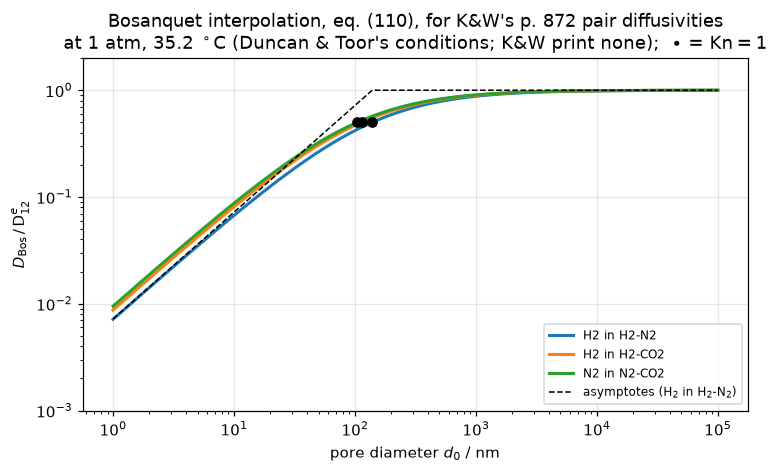

eq. (85) scalings: D_K(4T)/D_K(T) = 2.000000000000 (2), D_K(4M)/D_K(M) = 0.500000000000 (0.5), D_K(4d0)/D_K(d0) = 4.000000000000 (4)
worst deviation from the exponents printed in eq. (85): 0.00e+00


In [5]:
# --- eq. (85) scaling, and the transition curve ------------------------------
sT = knudsen_D(1e-7, 4 * T_REV, MOLAR["H2"]) / knudsen_D(1e-7, T_REV, MOLAR["H2"])
sM = knudsen_D(1e-7, T_REV, 4 * MOLAR["H2"]) / knudsen_D(1e-7, T_REV, MOLAR["H2"])
sD = knudsen_D(4e-7, T_REV, MOLAR["H2"]) / knudsen_D(1e-7, T_REV, MOLAR["H2"])
SCALE_DEV = max(abs(sT - 2.0), abs(sM - 0.5), abs(sD - 4.0))

d0s = np.logspace(-9, -4, 400)
fig, ax = plt.subplots(figsize=(7.0, 4.4))
for pair, dab in D_AB.items():
    a = pair.split("-")[0]
    dk = knudsen_D(d0s, T_REV, MOLAR[a])
    ax.loglog(d0s * 1e9, 1.0 / (1.0 / dk + 1.0 / dab) / dab, lw=2,
              label=f"{a} in {pair}")
    ax.plot([D0_CROSS[pair] * 1e9], [0.5], "o", ms=6, color="k", zorder=5)
ax.loglog(d0s * 1e9, np.minimum(knudsen_D(d0s, T_REV, MOLAR["H2"]) / D_AB["H2-N2"], 1.0),
          "k--", lw=1, label="asymptotes (H$_2$ in H$_2$-N$_2$)")
ax.set_xlabel("pore diameter $d_0$ / nm")
ax.set_ylabel(r"$D_{\rm Bos}\,/\,\mathrm{D}^e_{12}$")
ax.set_title(r"Bosanquet interpolation, eq. (110), for K&W's p. 872 pair "
             r"diffusivities" "\n"
             r"at 1 atm, 35.2 $^\circ$C (Duncan & Toor's conditions; K&W print "
             r"none);  $\bullet$ = $\mathrm{Kn}=1$")
ax.legend(fontsize=8, loc="lower right"); ax.set_ylim(1e-3, 2)
plt.tight_layout(); plt.show()

print(f"eq. (85) scalings: D_K(4T)/D_K(T) = {sT:.12f} (2), "
      f"D_K(4M)/D_K(M) = {sM:.12f} (0.5), D_K(4d0)/D_K(d0) = {sD:.12f} (4)")
print(f"worst deviation from the exponents printed in eq. (85): {SCALE_DEV:.2e}")

### Eq. (109) checked against eq. (82), symbolically

Eq. (109) is the equation everything on this page rests on, it was read once
off a scan, and its stoichiometric subscripts are exactly what the OCR
mangles. So it is derived independently, from eq. (82), before being used —
the `B3.1` pattern: *a transcription you can only read once should be checked
against something you can derive.*

For a binary mixture with flux ratio $N_2/N_1 = -\rho$, eq. (82) for species 1
reads $-\nabla c_1 = (x_2 N_1 - x_1 N_2)/\mathrm{D}^e_{12} + N_1/\mathrm{D}^e_{1M}$
(ideal gas, so $\nabla p_1 = RT\nabla c_1$), and solving it for
$D_1 = -N_1/\nabla c_1$ must reproduce eq. (109) with $\mathrm{D}_{\rm visc} = 0$.
Setting $\rho = 1$ must then give eq. (110).

In [6]:
_NA, _xa, _xb, _dab, _dam, _dbm, _rho, _kn = sp.symbols(
    "N_A x_A x_B D_AB D_AM D_BM rho Kn", positive=True)

# eq. (82), species 1 of a binary, with N_2 = -rho N_1
_row = (_xb * _NA - _xa * (-_rho * _NA)) / _dab + _NA / _dam
_from82 = sp.simplify(sp.expand(_row / _NA))                  # = 1/D_1
_eq109 = 1 / _dam + (_xb / _dab) * (1 + _rho * _xa / _xb)     # eq. (109), D_visc = 0
EQ109_RESID = sp.simplify(_from82 - _eq109)

_eq110 = sp.simplify(_eq109.subs(_rho, 1).subs(_xb, 1 - _xa))
EQ110_RESID = sp.simplify(_eq110 - (1 / _dam + 1 / _dab))

# The Bosanquet error in closed form.  Scaling by D_bos makes 1/D_AM + 1/D_AB = 1,
# with D_AM/D_bos = 1 + 1/Kn and D_AB/D_bos = 1 + Kn.
_scaled = {_dam: 1 + 1 / _kn, _dab: 1 + _kn}
_ratio = sp.simplify((_eq109 / (1 / _dam + 1 / _dab)).subs(_xb, 1 - _xa).subs(_scaled))
ERR_RESID = sp.simplify(_ratio - (1 + (_rho - 1) * _xa / (1 + _kn)))

# K&W condition (iii).  The viscous term of eq. (109) carries the factor
# sum_i (nu_i/nu_1)/D^e_iM = 1/D_AM - rho/D_BM.  Solve for the rho that kills
# it: eq. (85) makes D_BM/D_AM = sqrt(M_A/M_B), which is exactly the flux ratio
# Graham's law (eq. 107) imposes.  So condition (iii) IS "the viscous term
# vanishes", and it coincides with condition (ii), rho = 1, only when the two
# molar masses are equal.
VISC_FACTOR = sp.simplify(1 / _dam - _rho / _dbm)
RHO_NO_VISC = sp.solve(sp.Eq(VISC_FACTOR, 0), _rho)[0]
VISC_AT_RHO1 = sp.simplify(VISC_FACTOR.subs(_rho, 1))

print("1/D_1 from eq. (82)      :", sp.nsimplify(_from82))
print("eq. (109), D_visc = 0    :", sp.expand(_eq109))
print("difference               :", EQ109_RESID)
print("eq. (109) at rho = 1     :", _eq110, " -> eq. (110) residual:", EQ110_RESID)
print("D_Bos/D_1 (scaled)       :", sp.simplify(_ratio),
      "  == 1 + (rho-1) x_A/(1+Kn), residual:", ERR_RESID)
print("viscous factor              :", VISC_FACTOR)
print("   vanishes at rho =        :", RHO_NO_VISC,
      " = sqrt(M_A/M_B), i.e. exactly Graham's law, eq. (107) = condition (iii)")
print("   its value at rho = 1     :", VISC_AT_RHO1,
      " -> zero only if M_A = M_B")

1/D_1 from eq. (82)      : (D_AB + D_AM*(rho*x_A + x_B))/(D_AB*D_AM)
eq. (109), D_visc = 0    : 1/D_AM + rho*x_A/D_AB + x_B/D_AB
difference               : 0
eq. (109) at rho = 1     : (D_AB + D_AM)/(D_AB*D_AM)  -> eq. (110) residual: 0
D_Bos/D_1 (scaled)       : (Kn + rho*x_A - x_A + 1)/(Kn + 1)   == 1 + (rho-1) x_A/(1+Kn), residual: 0
viscous factor              : -rho/D_BM + 1/D_AM
   vanishes at rho =        : D_BM/D_AM  = sqrt(M_A/M_B), i.e. exactly Graham's law, eq. (107) = condition (iii)
   its value at rho = 1     : (-D_AM + D_BM)/(D_AM*D_BM)  -> zero only if M_A = M_B


**What that settles, and what it does not.** Eq. (109) as transcribed *is*
eq. (82) rearranged — the residual is identically zero — and it collapses to
eq. (110) exactly when $\rho = 1$, which is the review's condition (ii). The
transcription is therefore not in doubt. It also gives a closed form for the
whole question this page asks:

$$
\boxed{\;\frac{D_{\rm Bos}}{D_1} \;=\; 1 + \frac{(\rho - 1)\,x_1}{1 + \mathrm{Kn}}\;}
$$

The Bosanquet relation is exact when $\rho = 1$, for any Knudsen number; its
error grows linearly in the flux-ratio departure $\rho - 1$ and in the mole
fraction of the species itself; and — the part that is not obvious — it decays
as $1/(1+\mathrm{Kn})$, so it is **largest in the bulk-diffusion limit and
vanishes under Knudsen control**. That is a statement about the physics, not
about the algebra: under Knudsen control species do not exchange momentum with
each other at all, so what the other species is doing cannot matter, and any
formula that ignores the flux ratio is automatically right.

The last two symbolic lines identify the review's condition (iii). The viscous
term of eq. (109) carries the factor
$\sum_i(\nu_i/\nu_1)/\mathrm{D}^e_{iM} = 1/\mathrm{D}^e_{1M} -
\rho/\mathrm{D}^e_{2M}$, and solving for the $\rho$ that kills it gives
$\rho = \mathrm{D}^e_{2M}/\mathrm{D}^e_{1M} = \sqrt{M_1/M_2}$ — which is
precisely the flux ratio Graham's law imposes. **Condition (iii) is exactly
"the viscous term vanishes".** At $\rho = 1$ that factor is
$1/\mathrm{D}^e_{1M} - 1/\mathrm{D}^e_{2M}$, so conditions (ii) and (iii) are
two separate conditions and they close simultaneously only when
$M_1 = M_2$.

**This is algebra, and it is labelled as algebra.** It cannot detect an error
in the pymrm assembly, in the boundary conditions, or in the discretisation.
Everything below is there to test those.

### The solver

One skeleton, three flux closures, following the `A4.2` pattern:

- **`dgm`** — the dusty gas model as eq. (82) stands: build the $2\times2$
  matrix $[B^e]$ of eq. (87) at every face from the local composition and
  solve $(N) = -[B^e]^{-1}(\nabla c)$, which is eq. (86) for an ideal gas.
  **Nothing about the flux ratio is assumed** — it comes out of the solve.
- **`eq109`** — the scalar effective diffusivity of eq. (109), with the flux
  ratio $\rho$ prescribed. Diagonal: each species responds to its own
  gradient only.
- **`bosanquet`** — eq. (110), the same but with $\rho$ forced to 1, so the
  diffusivities are constants.

The three routes **differ only in the constitutive closure** — they share the
face reconstruction, both operators, the residual assembly and the same
`NumJac`, and only the body of `flux` changes. That is exactly what their
comparison can and cannot do: the scalar closures presume a flux ratio and
`dgm` does not, so comparing them tests *the presumption*; it cannot see a
discretisation error, because a wrong grid moves both routes together.

pymrm conventions, all of which matter here:

- **Layout `(n, 2)`** — spatial axis first, species last. Not `(n,)` with the
  species stacked: `NumJac` couples the last axis in full, so the field axis
  must be last or the stencil declares every cell coupled to every other.
- **`NumJac(shape, axes_diagonals=[0], axes_blocks=[-1])`** — the residual in
  a cell reads its neighbours through the face fluxes (`axes_diagonals=[0]`,
  meaningful here because `ndims = 2`) and the two species couple pointwise
  through $[B^e]$ (`axes_blocks=[-1]`).
- **Boundary conditions on the OUTWARD normal.** At a pellet centre the
  outward normal points inward, so symmetry is `{a:1, b:0, d:0}`; a fixed
  external composition is `{a:0, b:1, d:c_bnd}`. Each carries its physical
  equation in a comment.
- **`nu` in `construct_div` is geometry**: `0` slab, `1` cylinder, `2` sphere.
  It is swept below, because one of the results turns out to be blind to it
  and that has to be said.
- Constant operators are built once in `__init__`; only the composition-
  dependent flux is recomputed.

In [7]:
class Cell:
    """Binary porous medium in 1-D, fields (n, 2) = (c_A, c_B).

    Dimensionless unless dimensional diffusivities and boundary
    concentrations are passed in.  `phi` switches on a first-order
    heterogeneous reaction A -> nu_B B distributed through the pellet.
    """

    def __init__(self, n=200, geom=0, bc_left=None, bc_right=None,
                 dam=1.0, dbm=1.0, dab=1.0, phi=0.0, nu_b=1.0,
                 model="dgm", rho=None, b_offdiag=1.0):
        self.n, self.geom, self.shape = n, geom, (n, 2)
        self.dam, self.dbm, self.dab = dam, dbm, dab      # D^e_AM, D^e_BM, D^e_AB
        self.phi, self.nu_b, self.model = phi, nu_b, model
        self.rho = nu_b if rho is None else rho           # flux ratio -N_B/N_A
        # Sign of the [B^e] off-diagonals, i.e. of the friction terms of eq. (82).
        # +1 is the printed equation; -1 is the deliberate defect injected in V3.
        self.b_offdiag = b_offdiag
        self.x_f = np.linspace(0.0, 1.0, n + 1)
        self.x_c = 0.5 * (self.x_f[:-1] + self.x_f[1:])
        # bc on the OUTWARD normal, a dc/dn + b c = d.  Callers pass, at a
        # pellet centre, {a:1,b:0,d:0} (symmetry, dc/dn = 0) and at an outer
        # face {a:0,b:1,d:c_bnd} (imposed external concentration).
        self.grad, gb = construct_grad(self.shape, self.x_f, self.x_c,
                                       (bc_left, bc_right))
        self.grad_bc = np.asarray(gb.todense()).reshape((-1, 1))
        self.div = construct_div(self.shape, self.x_f, nu=geom)   # 0 slab 1 cyl 2 sph
        bl, blb = construct_boundary_value_matrices(
            self.shape, self.x_f, self.x_c, bc_left, bound_id=0)
        br, brb = construct_boundary_value_matrices(
            self.shape, self.x_f, self.x_c, bc_right, bound_id=1)
        self.bval = (bl, np.asarray(blb.todense()).reshape(-1),
                     br, np.asarray(brb.todense()).reshape(-1))
        # last axis = species (pointwise coupling through [B^e]); axis 0 = space,
        # whose neighbours the face fluxes read.  ndims = 2, so axes_diagonals
        # is meaningful; on a bare 1-D shape it would not be.
        self.numjac = NumJac(self.shape, axes_diagonals=[0], axes_blocks=[-1])

    # ---------------------------------------------------------------- helpers
    def faces(self, c):
        """Face values and face gradients of (c_A, c_B)."""
        bl, blb, br, brb = self.bval
        cf = np.empty((self.n + 1, 2))
        cf[1:-1] = 0.5 * (c[:-1] + c[1:])
        cf[0] = (bl @ c.reshape((-1, 1))).ravel() + blb
        cf[-1] = (br @ c.reshape((-1, 1))).ravel() + brb
        g = (self.grad @ c.reshape((-1, 1)) + self.grad_bc).reshape(self.n + 1, 2)
        return cf, g

    def b_matrix(self, xf):
        """[B^e] of K&W eq. (87) for n = 2.  B_ii = 1/D_iM + sum_k!=i x_k/D_ik,
        B_ij = -x_i/D_ij."""
        xa, xb = xf[:, 0], xf[:, 1]
        b = np.empty(xf.shape[:-1] + (2, 2))
        b[..., 0, 0] = 1.0 / self.dam + xb / self.dab
        b[..., 0, 1] = -self.b_offdiag * xa / self.dab
        b[..., 1, 0] = -self.b_offdiag * xb / self.dab
        b[..., 1, 1] = 1.0 / self.dbm + xa / self.dab
        return b

    def d_scalar(self, xf, bosanquet=False):
        """K&W eq. (109) with D_visc = 0, or eq. (110) if `bosanquet`.

        eq. (109) for species A with N_B/N_A = -rho:
            1/D_A = 1/D_AM + (x_B + rho x_A)/D_AB
        and for B with N_A/N_B = -1/rho:
            1/D_B = 1/D_BM + (x_A + x_B/rho)/D_AB
        """
        xa, xb, r = xf[:, 0], xf[:, 1], self.rho
        if bosanquet:
            ia = np.full_like(xa, 1.0 / self.dam + 1.0 / self.dab)
            ib = np.full_like(xb, 1.0 / self.dbm + 1.0 / self.dab)
        else:
            ia = 1.0 / self.dam + (xb + r * xa) / self.dab
            ib = 1.0 / self.dbm + (xa + xb / r) / self.dab
        return np.stack([1.0 / ia, 1.0 / ib], axis=1)

    # ----------------------------------------------------------- flux closures
    def flux(self, c):
        cf, g = self.faces(c)
        ct = np.maximum(cf.sum(axis=1, keepdims=True), 1e-300)
        xf = np.clip(cf / ct, 0.0, 1.0)
        if self.model == "dgm":       # eqs. (82)/(86)/(87): no flux ratio assumed
            return -np.linalg.solve(self.b_matrix(xf), g[..., None])[..., 0]
        return -self.d_scalar(xf, self.model == "bosanquet") * g

    def residual_fn(self, cflat):
        def f(cc):
            out = (self.div @ self.flux(cc).reshape((-1, 1))).reshape(self.shape)
            if self.phi:              # A -> nu_B B, first order in A
                r = self.phi ** 2 * np.clip(cc[..., 0:1], 0.0, None)
                out = out + np.concatenate([r, -self.nu_b * r], axis=-1)
            return out
        g, jac = self.numjac(f, cflat.reshape(self.shape))
        return g.reshape((-1, 1)), jac

    def solve(self, c0, maxfev=60, tol=1e-12):
        """Returns (c, relative Newton residual).

        The residual is normalised by the size of the individual terms it
        balances - max|N|/dx for the divergence, and phi^2 c for the source -
        NOT by their difference, which vanishes when there is no reaction.
        Convergence is ASSERTED from this number, never inferred from an
        identity holding.
        """
        r = newton(self.residual_fn, np.asarray(c0, float).reshape((-1, 1)),
                   maxfev=maxfev, tol=tol,
                   callback=lambda x, gg: clip_approach(x, gg, 0.0, None))
        c = r.x.reshape(self.shape)
        res, _ = self.residual_fn(r.x)
        scale = np.max(np.abs(self.flux(c))) / np.min(np.diff(self.x_f))
        if self.phi:
            scale = max(scale, self.phi ** 2 * np.max(np.abs(c[..., 0])))
        return c, float(np.max(np.abs(res)) / max(scale, 1e-300))


def d_groups(kn):
    """(D^e_AM, D^e_AB) scaled by D_Bos, given Kn = D^e_AB/D^e_AM."""
    return 1.0 + 1.0 / kn, 1.0 + kn


SYMMETRY = {"a": 1.0, "b": 0.0, "d": 0.0}       # dc/dn = 0 at a pellet centre


def dirichlet(ca, cb):
    return {"a": 0.0, "b": 1.0, "d": np.array([[ca, cb]])}


print("Cell ready.")

Cell ready.


## Results

### 1. The isobaric counter-diffusion cell — where condition (ii) fails

The textbook setting: a porous slab with fixed compositions on either side and
**equal total pressure** at both ends. Everyone applies Bosanquet here. But
$\nabla p = 0$ triggers eq. (107), so the flux ratio is not 1 — it is
$\sqrt{M_1/M_2}$, and Bosanquet's condition (ii) is violated by anything
except two gases of the same molar mass.

The `dgm` solver knows nothing about eq. (107). It is given equal total
concentration at both ends and left to find the fluxes, so Graham's law is a
*prediction* here.

In [8]:
XA1, XA2 = 0.9, 0.1                     # mole fractions of A at the two faces
RHO_GRAHAM = (MOLAR["H2"] / MOLAR["N2"]) ** GR_EXP     # eq. (107) for a binary


def isobaric_slab(kn, rho, m_a_over_m_b, model="dgm", n=200, b_offdiag=1.0):
    """Binary slab, equal total concentration at both ends, no reaction.

    eq. (85) makes D^e_iM proportional to M_i^(-1/2), so
    D^e_BM/D^e_AM = sqrt(M_A/M_B) = `m_a_over_m_b` ** 0.5.
    """
    dam, dab = d_groups(kn)
    s = Cell(n=n, geom=0, dam=dam, dbm=dam * m_a_over_m_b ** GR_EXP, dab=dab,
             bc_left=dirichlet(XA1, 1 - XA1), bc_right=dirichlet(XA2, 1 - XA2),
             model=model, rho=rho, b_offdiag=b_offdiag)
    c0 = (np.linspace(XA1, XA2, n)[:, None] * np.array([1.0, -1.0])
          + np.array([0.0, 1.0]))
    c, res = s.solve(c0)
    return s, c, res


KN_GRID = np.array([1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3])
iso = {}
GRAHAM_RESID, ISO_RES = 0.0, 0.0
mr = MOLAR["H2"] / MOLAR["N2"]          # M_A/M_B, A = H2 and B = N2
for kn in KN_GRID:
    row = {}
    for model in ("dgm", "bosanquet"):
        s, c, res = isobaric_slab(kn, RHO_GRAHAM, mr, model=model)
        N = s.flux(c)
        row[model] = abs(N[s.n // 2, 0])
        ISO_RES = max(ISO_RES, res)
        if model == "dgm":
            # eq. (107) as a PREDICTION: the solver was never told it
            gl = N[:, 0] * MOLAR["H2"] ** GR_EXP + N[:, 1] * MOLAR["N2"] ** GR_EXP
            row["ratio"] = float(-N[s.n // 2, 1] / N[s.n // 2, 0])
            GRAHAM_RESID = max(GRAHAM_RESID,
                               float(np.max(np.abs(gl)) / np.max(np.abs(N))))
    row["err"] = row["bosanquet"] / row["dgm"] - 1.0
    iso[kn] = row

# Can the Graham check fail?  Flip eq. (85)'s mass exponent, which is the one
# thing this comparison is supposed to be testing, and re-measure.
s_b, c_b, _ = isobaric_slab(1.0, RHO_GRAHAM, MOLAR["N2"] / MOLAR["H2"])   # inverted
N_b = s_b.flux(c_b)
GRAHAM_BROKEN = float(np.max(np.abs(
    N_b[:, 0] * MOLAR["H2"] ** GR_EXP + N_b[:, 1] * MOLAR["N2"] ** GR_EXP))
    / np.max(np.abs(N_b)))

ISO_RATIO_DEV = max(abs(r["ratio"] / RHO_GRAHAM - 1) for r in iso.values())
ISO_ERR_BULK = iso[KN_GRID[0]]["err"]
ISO_ERR_KNUD = iso[KN_GRID[-1]]["err"]

print(f"Graham's law, eq. (107): N_B/N_A should be -sqrt(M_A/M_B) = "
      f"-{RHO_GRAHAM:.6f} for H2 (A) in N2 (B)")
print(f"  worst |sum N_i sqrt(M_i)| / max|N| over the solves : {GRAHAM_RESID:.2e}")
print(f"  worst deviation of the solved ratio from Graham    : {ISO_RATIO_DEV:.2e}")
print(f"  the same, with eq. (85)'s mass exponent INVERTED   : {GRAHAM_BROKEN:.2e}"
      f"  <- so this check can fail")
print(f"  worst relative residual                            : {ISO_RES:.2e}\n")
print(f"{'Kn':>8} {'N_A (dgm)':>11} {'N_A (Bos)':>11} {'Bosanquet error':>16}")
for kn in KN_GRID:
    r = iso[kn]
    print(f"{kn:8.3g} {r['dgm']:11.5f} {r['bosanquet']:11.5f} {r['err']:15.2%}")

Graham's law, eq. (107): N_B/N_A should be -sqrt(M_A/M_B) = -0.268256 for H2 (A) in N2 (B)
  worst |sum N_i sqrt(M_i)| / max|N| over the solves : 1.64e-12
  worst deviation of the solved ratio from Graham    : 2.09e-11
  the same, with eq. (85)'s mass exponent INVERTED   : 1.55e-01  <- so this check can fail
  worst relative residual                            : 2.88e-11

      Kn   N_A (dgm)   N_A (Bos)  Bosanquet error
   0.001     1.36355     0.80000         -41.33%
    0.01     1.35333     0.80000         -40.89%
     0.1     1.26906     0.80000         -36.96%
       1     0.98979     0.80000         -19.17%
      10     0.82773     0.80000          -3.35%
     100     0.80291     0.80000          -0.36%
   1e+03     0.80029     0.80000          -0.04%


In [9]:
ISO_WORD = "under" if ISO_ERR_BULK < 0 else "over"
ISO_LOCAL_BULK = (RHO_GRAHAM - 1.0) * XA1 / (1.0 + KN_GRID[0])

display(Markdown(rf"""
For hydrogen counter-diffusing against nitrogen at equal total pressure, the
Bosanquet formula {ISO_WORD}estimates the hydrogen flux by
**{abs(ISO_ERR_BULK):.1%}** under bulk control and by
**{abs(ISO_ERR_KNUD):.2%}** under Knudsen control. The whole error is the flux
ratio: Graham's law brings nitrogen back at only {RHO_GRAHAM:.3f} times the
hydrogen flux, so a net molar flow towards the nitrogen side carries the
hydrogen along, and eq. (110) — which assumes the two fluxes cancel — cannot
see it.

The closed form predicts a *local* coefficient error of
$(\rho-1)x_A/(1+\mathrm{{Kn}})$, which at $x_A = {XA1}$ and
$\mathrm{{Kn}} = {KN_GRID[0]:g}$ is {ISO_LOCAL_BULK:+.1%}. The measured flux
error is {ISO_ERR_BULK:+.1%}, and the two differ because the flux integrates
$D_A(x_A)$ across the slab, where $x_A$ falls from {XA1} to {XA2}. That gap
between the local coefficient and the observable is what the solve is for.
"""))


For hydrogen counter-diffusing against nitrogen at equal total pressure, the
Bosanquet formula underestimates the hydrogen flux by
**41.3%** under bulk control and by
**0.04%** under Knudsen control. The whole error is the flux
ratio: Graham's law brings nitrogen back at only 0.268 times the
hydrogen flux, so a net molar flow towards the nitrogen side carries the
hydrogen along, and eq. (110) — which assumes the two fluxes cancel — cannot
see it.

The closed form predicts a *local* coefficient error of
$(\rho-1)x_A/(1+\mathrm{Kn})$, which at $x_A = 0.9$ and
$\mathrm{Kn} = 0.001$ is -65.8%. The measured flux
error is -41.3%, and the two differ because the flux integrates
$D_A(x_A)$ across the slab, where $x_A$ falls from 0.9 to 0.1. That gap
between the local coefficient and the observable is what the solve is for.


### 2. The reacting pellet — where conditions (ii) and (iii) both fail

A spherical pellet, pure A outside, first-order irreversible $A \to \nu_B B$
on the pore walls. Stoichiometry now fixes the flux ratio at $\rho = \nu_B$,
so condition (ii) fails for any $\nu_B \neq 1$, and mass conservation fixes
$M_B = M_A/\nu_B$ — no free molar mass, and hence no way to satisfy (iii)
either. A pressure gradient develops, and the
review quotes Jackson's (1977) closed form for it: with complete conversion of
A, the pressure at the pellet centre is $p_0 = \sqrt{\nu_B}\,p$.

**That is the check with power on this page.** It is a printed result, it
appears nowhere in the code, and it is not an interpolation: the solver is
given eq. (82), eq. (85), the stoichiometry and the boundary conditions, and
$\sqrt{\nu_B}$ has to come out.

In [10]:
N_PELLET = 600     # default pellet grid.  V2 refines to 4800 AT THE CONDITIONS OF
                   # THE SWEEP BELOW (Kn = 1e-3, phi = 30), where the boundary
                   # layer is thinnest, and reports what is left at n = 600.


def pellet(kn, nu_b, phi, n=N_PELLET, geom=2, model="dgm", b_offdiag=1.0):
    """Sphere (geom=2), pure A outside, A -> nu_B B first order in A.

    Mass conservation fixes M_B = M_A/nu_B, so eq. (85) fixes
    D^e_BM/D^e_AM = sqrt(M_A/M_B) = sqrt(nu_B).  Concentrations are scaled by
    the surface value of A, so c_A = 1, c_B = 0 at the surface and the total
    concentration there is 1.
    """
    dam, dab = d_groups(kn)
    p = Cell(n=n, geom=geom, dam=dam, dbm=dam * nu_b ** 0.5, dab=dab,
             phi=phi, nu_b=nu_b, model=model, b_offdiag=b_offdiag,
             bc_left=SYMMETRY,               # centre: dc/dn = 0
             bc_right=dirichlet(1.0, 0.0))   # surface: c_A = 1, c_B = 0
    c0 = np.zeros(p.shape); c0[:, 0] = 1.0
    c, res = p.solve(c0)
    return p, c, res


def observables(p, c):
    N = p.flux(c)
    return dict(p0=float(c.sum(axis=1)[0]),            # centre total concentration
                cA0=float(c[0, 0]),                    # centre concentration of A
                eta=float((p.geom + 1.0) * (-N[-1, 0]) / p.phi ** 2),
                NBA=float(-N[-1, 1] / N[-1, 0]))


KN_HI = 1e6                       # deep Knudsen control
NU_LIST = [1.0, 2.0, 3.0, 4.0]
jack, JACK_RES = {}, 0.0
for nb in NU_LIST:
    p, c, res = pellet(KN_HI, nb, 30.0)
    o = observables(p, c); JACK_RES = max(JACK_RES, res)
    jack[nb] = (o["p0"], abs(o["p0"] / np.sqrt(nb) - 1.0), o["cA0"], res)

JACK_DEV = max(v[1] for v in jack.values())
JACK_NU2 = jack[NU_B_PRINTED][0]

print("Jackson's pellet-centre pressure, quoted by K&W p. 892, in the Knudsen limit")
print(f"{'nu_B':>6} {'p_0/p solved':>14} {'sqrt(nu_B)':>12} {'rel dev':>10} "
      f"{'c_A(0)':>10} {'rel residual':>13}")
for nb in NU_LIST:
    v = jack[nb]
    print(f"{nb:6.1f} {v[0]:14.7f} {np.sqrt(nb):12.7f} {v[1]:10.2e} "
          f"{v[2]:10.2e} {v[3]:13.2e}")

# What IS that residual deviation?  Jackson's result is the Kn -> infinity
# limit, so the leftover bulk resistance must contribute a correction that dies
# as 1/Kn.  A discretisation error would not: it would sit at whatever the grid
# gives and stay there.  Push Kn out four decades and watch dev x Kn.
JACK_TAIL = []
for k in [1e5, 1e6, 1e7, 1e8]:
    p, c, res = pellet(k, NU_B_PRINTED, 30.0)
    dev = abs(float(c.sum(axis=1)[0]) / np.sqrt(NU_B_PRINTED) - 1.0)
    JACK_TAIL.append((k, dev, dev * k, res))
    JACK_RES = max(JACK_RES, res)
JACK_TAIL_SPREAD = (max(t[2] for t in JACK_TAIL) / min(t[2] for t in JACK_TAIL)) - 1.0

print("\nIs the leftover deviation the model or the solver?  It scales as 1/Kn:")
print(f"{'Kn':>10} {'rel dev':>12} {'dev x Kn':>12} {'rel residual':>13}")
for k, dev, prod, res in JACK_TAIL:
    print(f"{k:10.0e} {dev:12.3e} {prod:12.4f} {res:13.2e}")
print(f"dev x Kn constant to {JACK_TAIL_SPREAD:.2%} over four decades of Kn, on a "
      f"fixed grid,\nso the deviation is the finite-Kn bulk term of eq. (82), not "
      f"discretisation or Newton error.")

Jackson's pellet-centre pressure, quoted by K&W p. 892, in the Knudsen limit
  nu_B   p_0/p solved   sqrt(nu_B)    rel dev     c_A(0)  rel residual
   1.0      1.0000000    1.0000000   5.55e-16   5.63e-12      1.22e-14
   2.0      1.4142130    1.4142136   4.22e-07   5.63e-12      1.06e-14
   3.0      1.7320495    1.7320508   7.69e-07   5.63e-12      1.64e-14
   4.0      1.9999978    2.0000000   1.08e-06   5.63e-12      1.27e-14

Is the leftover deviation the model or the solver?  It scales as 1/Kn:
        Kn      rel dev     dev x Kn  rel residual
     1e+05    4.225e-06       0.4225      1.01e-14
     1e+06    4.225e-07       0.4225      1.06e-14
     1e+07    4.225e-08       0.4225      1.01e-14
     1e+08    4.227e-09       0.4227      1.03e-14
dev x Kn constant to 0.04% over four decades of Kn, on a fixed grid,
so the deviation is the finite-Kn bulk term of eq. (82), not discretisation or Newton error.


In [11]:
display(Markdown(rf"""
The review's sentence is *"Thus, for $\nu_B$ = 2, we have a
{DP_PRINTED:.0%} increase in pressure as we proceed towards the centre of the
pellet"*. The pymrm dusty-gas solve gives
**{JACK_NU2 - 1:.2%}**, and the review's own closed form
$p_0 = \sqrt{{\nu_B}}\,p$ gives $\sqrt{{2}} - 1$ =
{np.sqrt(NU_B_PRINTED) - 1:.2%}. The printed {DP_PRINTED:.0%} is the authors'
rounding of their own expression, not a different number; the solve reproduces
the expression to {jack[NU_B_PRINTED][1]:.1e} relative, and reproduces it for
$\nu_B$ = 1, 3 and 4 as well (worst {JACK_DEV:.1e}).

**What that last figure is.** It is not solver accuracy. Jackson's
$p_0 = \sqrt{{\nu_B}}\,p$ is the $\mathrm{{Kn}}\to\infty$ limit, and the solve
is run at a finite $\mathrm{{Kn}} = 10^{{{np.log10(KN_HI):.0f}}}$, so a
bulk-friction remnant of
eq. (82) is still present. The table above measures it: the deviation times
$\mathrm{{Kn}}$ is constant to {JACK_TAIL_SPREAD:.2%} across four decades of
$\mathrm{{Kn}}$ on a fixed grid, so it is a **model** residue that vanishes as
$1/\mathrm{{Kn}}$, not a discretisation or Newton error — those would not move
with $\mathrm{{Kn}}$ at all. The Newton residual, reported separately in the same
table, is {jack[NU_B_PRINTED][3]:.1e}.
"""))


The review's sentence is *"Thus, for $\nu_B$ = 2, we have a
40% increase in pressure as we proceed towards the centre of the
pellet"*. The pymrm dusty-gas solve gives
**41.42%**, and the review's own closed form
$p_0 = \sqrt{\nu_B}\,p$ gives $\sqrt{2} - 1$ =
41.42%. The printed 40% is the authors'
rounding of their own expression, not a different number; the solve reproduces
the expression to 4.2e-07 relative, and reproduces it for
$\nu_B$ = 1, 3 and 4 as well (worst 1.1e-06).

**What that last figure is.** It is not solver accuracy. Jackson's
$p_0 = \sqrt{\nu_B}\,p$ is the $\mathrm{Kn}\to\infty$ limit, and the solve
is run at a finite $\mathrm{Kn} = 10^{6}$, so a
bulk-friction remnant of
eq. (82) is still present. The table above measures it: the deviation times
$\mathrm{Kn}$ is constant to 0.04% across four decades of
$\mathrm{Kn}$ on a fixed grid, so it is a **model** residue that vanishes as
$1/\mathrm{Kn}$, not a discretisation or Newton error — those would not move
with $\mathrm{Kn}$ at all. The Newton residual, reported separately in the same
table, is 1.1e-14.


**Is that agreement worth anything?** Validation section V3 measures it
directly. Two properties are worth noting first, and both are checked below:
$p_0/\sqrt{\nu_B}\,p$ must be independent of pellet geometry, of the Thiele
modulus and of the grid — Jackson's result contains none of them — and it is
*not* a discriminator between the dusty gas model and Bosanquet, because in
the Knudsen limit the two coincide.

What it does test is narrower than it looks: the $M^{-1/2}$ of eq. (85) and
the stoichiometric closure, both measured in V3. It does **not** test the
signs of the friction terms of eq. (82) — V3 flips the off-diagonals of
$[B^e]$ and the centre pressure moves by about as much as the finite-Kn
residue this check already carries, orders of magnitude below the defects it
does catch — and there
is no ideal-gas step to test, because the solver works in concentrations from
end to end and never forms a partial pressure. The checks that do catch a
flipped friction sign are V1 (the two closures against each other) and
Graham's law; V3 measures both.

### 3. The Bosanquet error across the whole transition

Now sweep the Knudsen number, with both closures, and read off what the
approximation costs in the two observables an engineer actually uses: the
internal pressure and the effectiveness factor.

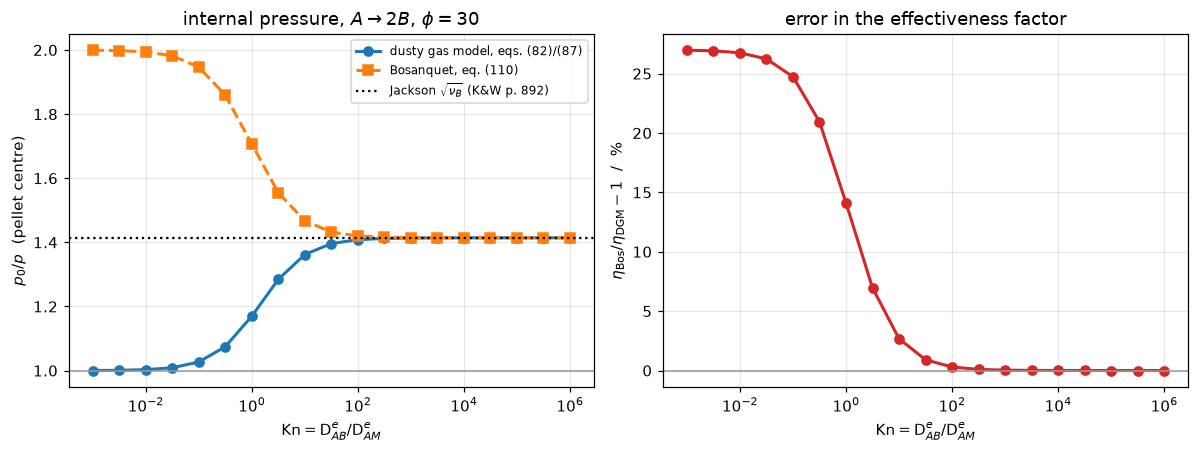

       Kn   p0/p DGM   p0/p Bos   eta DGM   eta Bos  eta error
    0.001    1.00029    1.99941   0.07613   0.09666    26.97%
   0.0316    1.00888    1.98204   0.07657   0.09666    26.24%
        1    1.16957    1.70711   0.08470   0.09666    14.12%
     31.6    1.39614    1.43217   0.09580   0.09666     0.91%
    1e+03    1.41362    1.41480   0.09664   0.09666     0.03%
 3.16e+04    1.41419    1.41423   0.09666   0.09666     0.00%
    1e+06    1.41421    1.41421   0.09666   0.09666     0.00%

Bosanquet centre pressure vs its own closed form nu_B D_A/D_B: worst 2.82e-12

effectiveness-factor error at Kn = 0.001, n = 600, against the Thiele modulus:
   phi =    10: 25.49%   phi =    30: 26.97%   phi =   100: 27.66%
worst relative residual over the sweep: 3.45e-11


In [12]:
KN_SWEEP = np.logspace(-3, 6, 19)
NU_B = NU_B_PRINTED
PHI = 30.0          # the Thiele modulus of the sweep. The Bosanquet error is a
                    # function of it, so it is named beside every number below
                    # and its sensitivity is measured at the end of this cell.
sweep, SWEEP_RES = {}, 0.0
for kn in KN_SWEEP:
    row = {}
    for model in ("dgm", "bosanquet"):
        p, c, res = pellet(kn, NU_B, PHI, model=model)
        row[model] = observables(p, c)
        SWEEP_RES = max(SWEEP_RES, res)
        if model == "bosanquet":
            # closed form for the Bosanquet model's own centre pressure:
            # constant D means D_B c_B + nu_B D_A c_A is harmonic with zero
            # flux at the centre, so c_t(0) = nu_B D_A/D_B.
            dA = 1.0 / (1.0 / p.dam + 1.0 / p.dab)
            dB = 1.0 / (1.0 / p.dbm + 1.0 / p.dab)
            row["bos_p0_closed"] = NU_B * dA / dB
    row["eta_ratio"] = row["bosanquet"]["eta"] / row["dgm"]["eta"]
    sweep[kn] = row

BOS_P0_CLOSED_DEV = max(abs(r["bosanquet"]["p0"] / r["bos_p0_closed"] - 1)
                        for r in sweep.values())
ETA_BULK = sweep[KN_SWEEP[0]]["eta_ratio"]
ETA_KNUD = sweep[KN_SWEEP[-1]]["eta_ratio"]
ETA_KN1 = sweep[KN_SWEEP[np.argmin(abs(np.log10(KN_SWEEP)))]]["eta_ratio"]

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
kn = KN_SWEEP
axes[0].semilogx(kn, [sweep[k]["dgm"]["p0"] for k in kn], "o-", lw=2,
                 label="dusty gas model, eqs. (82)/(87)")
axes[0].semilogx(kn, [sweep[k]["bosanquet"]["p0"] for k in kn], "s--", lw=2,
                 label="Bosanquet, eq. (110)")
axes[0].axhline(np.sqrt(NU_B), color="k", ls=":",
                label=r"Jackson $\sqrt{\nu_B}$ (K&W p. 892)")
axes[0].axhline(1.0, color="0.6", lw=1)
axes[0].set_xlabel(r"$\mathrm{Kn} = \mathrm{D}^e_{AB}/\mathrm{D}^e_{AM}$")
axes[0].set_ylabel(r"$p_0/p$  (pellet centre)")
axes[0].set_title(f"internal pressure, $A\\to{NU_B:.0f}B$, $\\phi={PHI:.0f}$")
axes[0].legend(fontsize=8)

axes[1].semilogx(kn, [(sweep[k]["eta_ratio"] - 1) * 100 for k in kn], "o-", lw=2,
                 color="C3")
axes[1].axhline(0.0, color="0.6", lw=1)
axes[1].set_xlabel(r"$\mathrm{Kn} = \mathrm{D}^e_{AB}/\mathrm{D}^e_{AM}$")
axes[1].set_ylabel(r"$\eta_{\rm Bos}/\eta_{\rm DGM} - 1$  /  %")
axes[1].set_title("error in the effectiveness factor")
plt.tight_layout(); plt.show()

print(f"{'Kn':>9} {'p0/p DGM':>10} {'p0/p Bos':>10} {'eta DGM':>9} {'eta Bos':>9} "
      f"{'eta error':>10}")
for k in KN_SWEEP[::3]:
    r = sweep[k]
    print(f"{k:9.3g} {r['dgm']['p0']:10.5f} {r['bosanquet']['p0']:10.5f} "
          f"{r['dgm']['eta']:9.5f} {r['bosanquet']['eta']:9.5f} "
          f"{r['eta_ratio']-1:9.2%}")
print(f"\nBosanquet centre pressure vs its own closed form nu_B D_A/D_B: "
      f"worst {BOS_P0_CLOSED_DEV:.2e}")

# The bulk-limit effectiveness-factor error is NOT a universal constant: it
# depends on the Thiele modulus, which is a free parameter of the pellet and not
# of the Bosanquet relation.  Measure that dependence rather than hide it.
PHI_LIST = [10.0, 30.0, 100.0]
eta_phi = {}
for ph in PHI_LIST:
    r = {}
    for model in ("dgm", "bosanquet"):
        pp, cc, res = pellet(KN_SWEEP[0], NU_B, ph, model=model)
        r[model] = observables(pp, cc)["eta"]
        SWEEP_RES = max(SWEEP_RES, res)
    eta_phi[ph] = r["bosanquet"] / r["dgm"] - 1.0
ETA_PHI_LO, ETA_PHI_HI = eta_phi[PHI_LIST[0]], eta_phi[PHI_LIST[-1]]

print(f"\neffectiveness-factor error at Kn = {KN_SWEEP[0]:g}, n = {N_PELLET}, "
      f"against the Thiele modulus:")
print("   " + "   ".join(f"phi = {ph:5.0f}: {eta_phi[ph]:6.2%}" for ph in PHI_LIST))
print(f"worst relative residual over the sweep: {SWEEP_RES:.2e}")

In [13]:
P0_BULK_DGM = sweep[KN_SWEEP[0]]["dgm"]["p0"]
P0_BULK_BOS = sweep[KN_SWEEP[0]]["bosanquet"]["p0"]

display(Markdown(rf"""
**Read the left panel from the right.** Deep in the Knudsen regime the two
closures sit on top of each other, both on Jackson's $\sqrt{{\nu_B}}$ line.
Coming left, the dusty gas model relaxes towards $p_0/p = 1$ — with bulk
diffusion available, the extra moles of B leave without building a pressure —
while the Bosanquet model runs the other way, to
{P0_BULK_BOS:.3f}, because constant diffusivities
force the total concentration at the centre to
$\nu_B D_A/D_B$ regardless of how the species actually couple. At
$\mathrm{{Kn}} = 10^{{-3}}$ the dusty gas model says the internal pressure
rise is {P0_BULK_DGM - 1:.2%} and Bosanquet says
{P0_BULK_BOS - 1:.0%}.

**The effectiveness factor** is the number that reaches a reactor model. For
this pellet — $A\to{NU_B:.0f}B$, $\phi = {PHI:.0f}$, {N_PELLET} cells —
Bosanquet overestimates it by **{ETA_BULK - 1:.1%}** under bulk control,
{ETA_KN1 - 1:.1%} at $\mathrm{{Kn}} = 1$, and {ETA_KNUD - 1:.1e} (relative)
under Knudsen control.

**Those percentages are conditions-specific, and the conditions are the Thiele
modulus and the grid.** At $\mathrm{{Kn}} = {KN_SWEEP[0]:g}$ the same error is
{ETA_PHI_LO:.1%} at $\phi = {PHI_LIST[0]:.0f}$ and {ETA_PHI_HI:.1%} at
$\phi = {PHI_LIST[-1]:.0f}$ — it grows with $\phi$, because a thinner reacting
shell samples the composition where $x_A$ is closest to 1 and the closed form
$(\rho-1)x_A/(1+\mathrm{{Kn}})$ is largest. The grid dependence is settled in
V2. What is *not* conditions-specific — and is the actual result — is the
**shape**: monotone decay in $\mathrm{{Kn}}$, with the error dying under
Knudsen control at every $\phi$.

So the interpolation whose entire purpose is to add the
Knudsen resistance is accurate when the Knudsen resistance dominates and
inaccurate when it does not — and the practical reading is the reverse of the
usual instinct: *if your pores are small enough for Knudsen diffusion to
matter, Bosanquet is fine; if they are not, do not reach for it just because
the two terms are still comparable.*
"""))


**Read the left panel from the right.** Deep in the Knudsen regime the two
closures sit on top of each other, both on Jackson's $\sqrt{\nu_B}$ line.
Coming left, the dusty gas model relaxes towards $p_0/p = 1$ — with bulk
diffusion available, the extra moles of B leave without building a pressure —
while the Bosanquet model runs the other way, to
1.999, because constant diffusivities
force the total concentration at the centre to
$\nu_B D_A/D_B$ regardless of how the species actually couple. At
$\mathrm{Kn} = 10^{-3}$ the dusty gas model says the internal pressure
rise is 0.03% and Bosanquet says
100%.

**The effectiveness factor** is the number that reaches a reactor model. For
this pellet — $A\to2B$, $\phi = 30$, 600 cells —
Bosanquet overestimates it by **27.0%** under bulk control,
14.1% at $\mathrm{Kn} = 1$, and 3.0e-07 (relative)
under Knudsen control.

**Those percentages are conditions-specific, and the conditions are the Thiele
modulus and the grid.** At $\mathrm{Kn} = 0.001$ the same error is
25.5% at $\phi = 10$ and 27.7% at
$\phi = 100$ — it grows with $\phi$, because a thinner reacting
shell samples the composition where $x_A$ is closest to 1 and the closed form
$(\rho-1)x_A/(1+\mathrm{Kn})$ is largest. The grid dependence is settled in
V2. What is *not* conditions-specific — and is the actual result — is the
**shape**: monotone decay in $\mathrm{Kn}$, with the error dying under
Knudsen control at every $\phi$.

So the interpolation whose entire purpose is to add the
Knudsen resistance is accurate when the Knudsen resistance dominates and
inaccurate when it does not — and the practical reading is the reverse of the
usual instinct: *if your pores are small enough for Knudsen diffusion to
matter, Bosanquet is fine; if they are not, do not reach for it just because
the two terms are still comparable.*


### 4. The closed form, against the solves

The boxed expression $D_{\rm Bos}/D_1 = 1 + (\rho-1)x_A/(1+\mathrm{Kn})$ was
derived above from eq. (109) and eq. (110) with sympy. Here it is evaluated
against the diffusivities the solver actually used, at every face of every
converged pellet and slab solution. This is an **algebraic identity** — both
sides are built from `d_scalar` — so it confirms the derivation and the
implementation of eq. (109), and nothing about the physics. It is shown
because it is the map, and the map is the page's contribution.

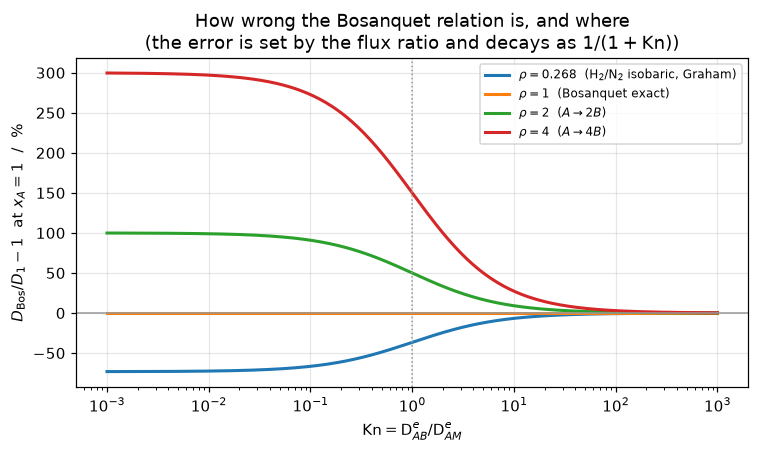

closed form vs the coefficients the solver used, all faces, all Kn: 6.66e-16  (algebraic identity)
At x_A = 1 the local error is (rho-1)/(1+Kn):
  Kn =   0.001:  A->2B   99.90%   A->4B  299.70%   H2/N2 isobaric  -73.10%
  Kn =     0.1:  A->2B   90.91%   A->4B  272.73%   H2/N2 isobaric  -66.52%
  Kn =       1:  A->2B   50.00%   A->4B  150.00%   H2/N2 isobaric  -36.59%
  Kn =      10:  A->2B    9.09%   A->4B   27.27%   H2/N2 isobaric   -6.65%
  Kn =   1e+03:  A->2B    0.10%   A->4B    0.30%   H2/N2 isobaric   -0.07%


In [14]:
CLOSED_DEV = 0.0
for kn in KN_SWEEP:
    p, c, _ = pellet(kn, NU_B, PHI)
    cf, _ = p.faces(c)
    xf = np.clip(cf / np.maximum(cf.sum(1, keepdims=True), 1e-300), 0, 1)
    got = p.d_scalar(xf, True)[:, 0] / p.d_scalar(xf, False)[:, 0]
    pred = 1.0 + (p.rho - 1.0) * xf[:, 0] / (1.0 + kn)
    CLOSED_DEV = max(CLOSED_DEV, float(np.max(np.abs(got - pred))))

fig, ax = plt.subplots(figsize=(7.0, 4.2))
knc = np.logspace(-3, 3, 300)
for rho, lab in [(0.268, r"$\rho=0.268$  (H$_2$/N$_2$ isobaric, Graham)"),
                 (1.0, r"$\rho=1$  (Bosanquet exact)"),
                 (2.0, r"$\rho=2$  ($A\to2B$)"),
                 (4.0, r"$\rho=4$  ($A\to4B$)")]:
    ax.semilogx(knc, (rho - 1.0) * 1.0 / (1.0 + knc) * 100, lw=2, label=lab)
ax.axhline(0, color="0.6", lw=1); ax.axvline(1.0, color="0.6", ls=":", lw=1)
ax.set_xlabel(r"$\mathrm{Kn} = \mathrm{D}^e_{AB}/\mathrm{D}^e_{AM}$")
ax.set_ylabel(r"$D_{\rm Bos}/D_1 - 1$  at $x_A = 1$  /  %")
ax.set_title("How wrong the Bosanquet relation is, and where\n"
             "(the error is set by the flux ratio and decays as $1/(1+\\mathrm{Kn})$)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print(f"closed form vs the coefficients the solver used, all faces, all Kn: "
      f"{CLOSED_DEV:.2e}  (algebraic identity)")
print("At x_A = 1 the local error is (rho-1)/(1+Kn):")
for kn in [1e-3, 1e-1, 1e0, 1e1, 1e3]:
    print(f"  Kn = {kn:7.3g}:  A->2B {1.0/(1+kn):8.2%}   "
          f"A->4B {3.0/(1+kn):8.2%}   H2/N2 isobaric "
          f"{(RHO_GRAHAM-1)/(1+kn):8.2%}")

### 5. The review's two scaling claims

p. 887 states them plainly: the pair diffusivities are inversely proportional
to pressure and independent of pore size, so under bulk control the fluxes are
independent of both; the Knudsen diffusivities are independent of pressure and
proportional to pore size, so under Knudsen control the fluxes are
proportional to both. Measured as log–log slopes on the dimensional isobaric
H₂/N₂ slab, with the review's own printed $\mathrm{D}_{12}$ at 1 atm scaled as
$1/p$.

In [15]:
DELTA = 1.0e-3      # m, slab thickness (only sets the flux scale)


def dim_slab_flux(p_tot, d0, n=120):
    """Isobaric H2/N2 slab at pressure p_tot and pore diameter d0. Dimensional."""
    dab = D_AB["H2-N2"] * P_ATM / p_tot          # D_ij ~ 1/p  (kinetic theory)
    dam = knudsen_D(d0, T_REV, MOLAR["H2"])      # eq. (85): ~ d0, independent of p
    dbm = knudsen_D(d0, T_REV, MOLAR["N2"])
    ct = p_tot / (RGAS * T_REV)
    s = Cell(n=n, geom=0, dam=dam, dbm=dbm, dab=dab,
             bc_left=dirichlet(XA1 * ct, (1 - XA1) * ct),
             bc_right=dirichlet(XA2 * ct, (1 - XA2) * ct))
    c0 = ct * (np.linspace(XA1, XA2, n)[:, None] * np.array([1.0, -1.0])
               + np.array([0.0, 1.0]))
    c, res = s.solve(c0)
    return abs(s.flux(c)[n // 2, 0]) / DELTA, res, dab / dam


def loglog_slope(xs, ys):
    return float(np.polyfit(np.log(xs), np.log(ys), 1)[0])


scal, SCAL_RES = {}, 0.0
for tag, d0, ps in [("Knudsen control", 20e-9, np.array([1e3, 3e3, 1e4, 3e4])),
                    ("bulk control", 20e-6, np.array([1e4, 3e4, 1e5, 3e5]))]:
    out = [dim_slab_flux(p, d0) for p in ps]
    SCAL_RES = max(SCAL_RES, max(o[1] for o in out))
    scal[("p", tag)] = (loglog_slope(ps, [o[0] for o in out]),
                        out[0][2], out[-1][2], d0)
for tag, p_tot, ds in [("Knudsen control", 1e3, np.array([1e-8, 3e-8, 1e-7, 3e-7])),
                       ("bulk control", 1e7, np.array([1e-8, 3e-8, 1e-7, 3e-7]))]:
    out = [dim_slab_flux(p_tot, d) for d in ds]
    SCAL_RES = max(SCAL_RES, max(o[1] for o in out))
    scal[("d0", tag)] = (loglog_slope(ds, [o[0] for o in out]),
                         out[0][2], out[-1][2], p_tot)

print("K&W p. 887, measured as log-log slopes of the slab flux")
print(f"{'sweep':>5} {'regime':>16} {'Kn range':>22} {'slope':>9} {'K&W says':>10}")
for (var, tag), (sl, kn_lo, kn_hi, other) in scal.items():
    says = "1" if tag == "Knudsen control" else "0"
    print(f"{var:>5} {tag:>16} {kn_lo:10.3g} .. {kn_hi:<9.3g} {sl:9.4f} {says:>10}")
SCAL_KNUD = max(abs(scal[("p", "Knudsen control")][0] - 1),
                abs(scal[("d0", "Knudsen control")][0] - 1))
SCAL_BULK = max(abs(scal[("p", "bulk control")][0]),
                abs(scal[("d0", "bulk control")][0]))
print(f"\nworst departure from the stated exponents: {SCAL_KNUD:.3f} (Knudsen, "
      f"expected 1), {SCAL_BULK:.3f} (bulk, expected 0)")
print("Both departures are finite-Kn effects: the sweeps move Kn by 30x, so "
      "neither regime\nis pure across a sweep. They shrink as the sweeps are "
      "pushed further into their limits.")

K&W p. 887, measured as log-log slopes of the slab flux
sweep           regime               Kn range     slope   K&W says
    p  Knudsen control        704 .. 23.5         0.9927          1
    p     bulk control     0.0704 .. 0.00235      0.0333          0
   d0  Knudsen control   1.41e+03 .. 46.9         0.9963          1
   d0     bulk control      0.141 .. 0.00469      0.0626          0

worst departure from the stated exponents: 0.007 (Knudsen, expected 1), 0.063 (bulk, expected 0)
Both departures are finite-Kn effects: the sweeps move Kn by 30x, so neither regime
is pure across a sweep. They shrink as the sweeps are pushed further into their limits.


## Validation

Ranked, and **not of equal weight**. There is no measurement anywhere on this
page — the review prints one dusty-gas/experiment comparison (Fig. 44) and it
is ternary and belongs to `A4.3`. **This page is tier 6**: printed constants,
printed closed forms, and internal identities. It must not be described as
validated against experiment.

1. **A stated result, reproduced.** Jackson's pellet-centre pressure
   $p_0 = \sqrt{\nu_B}\,p$, quoted by the review on p. 892 with its "40 %
   increase" for $\nu_B = 2$. The solver encodes it nowhere. Section V3
   measures what that agreement is sensitive to.
2. **A second stated result, reproduced.** Graham's law, eq. (107), emerges
   from the isobaric slab, which is given equal total concentration at both
   ends and nothing else. It is an identity of eqs. (82)+(85) once
   $\nabla p = 0$ is imposed, so it is not independent evidence for the model
   — what it checks is the $M^{-1/2}$ exponent of eq. (85) and the sign
   structure of eq. (82). Inverting that exponent lifts the residual from
   $10^{-12}$ to $10^{-1}$, which is measured in the cell itself, so the check
   is not vacuous.
3. **The review's two scaling claims**, measured as log–log slopes.
4. **The transcription of eq. (109)**, twice: re-derived symbolically from
   eq. (82), and collapsing to eq. (110) at $\rho = 1$. Both exact. Algebra;
   labelled as algebra.
5. **Two closures that differ only in the constitutive relation.** The `dgm`
   route inverts $[B^e]$ and presumes no flux ratio; `eq109`/`bosanquet` are
   scalar and presume one. Everything else — grid, operators, residual
   assembly, Jacobian — is shared, so their agreement is a check on the
   *presumption* and not on the discretisation. It is the check that catches a
   sign flip in the friction terms of eq. (82), which V3 shows the headline
   check cannot.
6. **Grid convergence** at second order, and the headline number refined at its
   own conditions until the quoted digits are the model's; the Newton residual
   is asserted separately on every solve, because, as V3 shows, the headline
   number cannot see an unconverged solve.
7. **The geometry index**, against the classical effectiveness factor of a
   slab, a cylinder and a sphere in the $\rho = 1$ limit where the pellet
   problem is linear. Nothing else on the page can see a wrong `nu`.
8. **Internal consistency**: the Bosanquet model's centre pressure against its
   own closed form $\nu_B D_A/D_B$; the closed-form error map against the
   coefficients the solver used. Both algebraic.

### V1. The two closures against each other

Where the flux ratio the scalar closure presumes is the one the dusty gas
model produces, the two must agree. Where it is not, they must not. Both
directions are checked, because only the second one has any power.

In [16]:
# (a) pellet: stoichiometry fixes rho = nu_B, so eq. (109) is exact there
CLOSURE_AGREE, CLOSURE_RES = 0.0, 0.0
for kn in [1e-2, 1e0, 1e2]:
    for nb in [1.0, 2.0, 4.0]:
        pa, ca, ra = pellet(kn, nb, 20.0, model="dgm")
        pb, cb, rb = pellet(kn, nb, 20.0, model="eq109")
        CLOSURE_RES = max(CLOSURE_RES, ra, rb)
        CLOSURE_AGREE = max(CLOSURE_AGREE,
                            float(np.max(np.abs(ca - cb)) / np.max(np.abs(ca))))

# (b) the same comparison with the WRONG flux ratio handed to eq. (109):
#     rho = 1 (Bosanquet's assumption) where the stoichiometry says nu_B = 2
pw, cw, _ = pellet(1e-2, 2.0, 20.0, model="bosanquet")
pt, ct_, _ = pellet(1e-2, 2.0, 20.0, model="dgm")
CLOSURE_WRONG = float(np.max(np.abs(cw - ct_)) / np.max(np.abs(ct_)))

print(f"dgm vs eq. (109) with the flux ratio the stoichiometry fixes : "
      f"{CLOSURE_AGREE:.2e}  (9 solves)")
print(f"   worst relative residual over those solves                  : "
      f"{CLOSURE_RES:.2e}")
print(f"dgm vs eq. (110), i.e. the flux ratio forced to 1 at Kn=0.01 : "
      f"{CLOSURE_WRONG:.2e}")
print(f"\nThe first number says the scalar reduction of eq. (82) is faithful; the "
      f"second\nsays the comparison is not vacuous - handing it the wrong flux "
      f"ratio moves it by\n{np.log10(CLOSURE_WRONG/CLOSURE_AGREE):.0f} orders of "
      f"magnitude.")

dgm vs eq. (109) with the flux ratio the stoichiometry fixes : 2.43e-15  (9 solves)
   worst relative residual over those solves                  : 1.89e-12
dgm vs eq. (110), i.e. the flux ratio forced to 1 at Kn=0.01 : 9.89e-01

The first number says the scalar reduction of eq. (82) is faithful; the second
says the comparison is not vacuous - handing it the wrong flux ratio moves it by
15 orders of magnitude.


### V2. Grid convergence, and the residual asserted separately

Two studies, because they license different things. The first establishes the
*order* of the scheme on the effectiveness factor. The second refines the
**headline number at the conditions it is quoted at** — $\mathrm{Kn} = 10^{-3}$,
$\phi = 30$, where the reacting shell is three times thinner than in the first
study — so that the digits printed above are known to be the model's and not
the mesh's.

In [17]:
grid = {}
for n in [50, 100, 200, 400, 800]:
    p, c, res = pellet(1.0, NU_B, 10.0, n=n)
    grid[n] = (observables(p, c)["eta"], res)
ns = sorted(grid)
diffs = [abs(grid[ns[i + 1]][0] - grid[ns[i]][0]) for i in range(len(ns) - 1)]
ORDER = float(np.log2(diffs[-2] / diffs[-1]))
GRID_RES = max(v[1] for v in grid.values())

print(f"(a) order of the scheme:  eta, Kn = 1, phi = 10, A -> {NU_B:.0f}B")
print(f"{'n':>6} {'eta':>14} {'|diff|':>12} {'rel residual':>13}")
for i, n in enumerate(ns):
    d = f"{diffs[i-1]:12.3e}" if i else " " * 12
    print(f"{n:6d} {grid[n][0]:14.10f} {d} {grid[n][1]:13.2e}")
print(f"observed order between the last two refinements: {ORDER:.2f}")

(a) order of the scheme:  eta, Kn = 1, phi = 10, A -> 2B
     n            eta       |diff|  rel residual
    50   0.2376653390                   2.99e-15
   100   0.2380611347    3.958e-04      7.69e-15
   200   0.2381349797    7.384e-05      2.01e-14
   400   0.2381497037    1.472e-05      3.37e-14
   800   0.2381528756    3.172e-06      8.82e-14
observed order between the last two refinements: 2.21


In [18]:
# (b) the headline number, refined at ITS OWN conditions
head = {}
for n in [150, 300, N_PELLET, 1200, 2400, 4800]:
    row = {}
    for model in ("dgm", "bosanquet"):
        p, c, res = pellet(KN_SWEEP[0], NU_B, PHI, n=n, model=model)
        row[model] = observables(p, c)["eta"]
        GRID_RES = max(GRID_RES, res)
    head[n] = row["bosanquet"] / row["dgm"] - 1.0

ETA_BULK_CONVERGED = head[max(head)]
ETA_BULK_GRID_ERR = abs(head[N_PELLET] - ETA_BULK_CONVERGED)
ETA_BULK_N300_ERR = abs(head[300] - ETA_BULK_CONVERGED)

print(f"(b) the headline Bosanquet error in eta, at the sweep's own conditions: "
      f"Kn = {KN_SWEEP[0]:g}, phi = {PHI:.0f}, A -> {NU_B:.0f}B")
print(f"{'n':>6} {'eta error':>12} {'|diff|':>12}")
hn = sorted(head)
for i, n in enumerate(hn):
    d = f"{abs(head[n]-head[hn[i-1]]):12.2e}" if i else " " * 12
    print(f"{n:6d} {head[n]:11.4%} {d}")
print(f"\nconverged value (n = {max(head)}) : {ETA_BULK_CONVERGED:.4%}")
print(f"the sweep's n = {N_PELLET} is {ETA_BULK_GRID_ERR:.2e} from it "
      f"({ETA_BULK_GRID_ERR/abs(ETA_BULK_CONVERGED):.2%} of the value); "
      f"n = 300 would be {ETA_BULK_N300_ERR:.2e} out")
print(f"so the headline is quoted as {ETA_BULK_CONVERGED:.1%} at phi = {PHI:.0f} - "
      f"two significant figures the grid supports.")
print(f"worst relative residual over both refinement studies: {GRID_RES:.2e}")

(b) the headline Bosanquet error in eta, at the sweep's own conditions: Kn = 0.001, phi = 30, A -> 2B
     n    eta error       |diff|
   150    27.3083%             
   300    27.0253%     2.83e-03
   600    26.9729%     5.25e-04
  1200    26.9627%     1.02e-04
  2400    26.9605%     2.13e-05
  4800    26.9601%     4.78e-06

converged value (n = 4800) : 26.9601%
the sweep's n = 600 is 1.28e-04 from it (0.05% of the value); n = 300 would be 6.53e-04 out
so the headline is quoted as 27.0% at phi = 30 - two significant figures the grid supports.
worst relative residual over both refinement studies: 1.40e-10


### V3. What the $\sqrt{\nu_B}$ agreement is actually sensitive to

The most common defect in this repository is an agreement number that is
algebraically guaranteed and is presented as evidence. So the headline result
is broken on purpose, seven ways, and the table records both what moves it and
what does not. **Every "cannot detect" row below is a claim this page is
therefore not making.**

In [19]:
def broken(kind, kn=KN_HI, nu_b=NU_B, phi=30.0, n=N_PELLET, geom=2, model="dgm",
           maxfev=60):
    """Rebuild the Knudsen-limit pellet with one deliberate defect."""
    dam, dab = d_groups(kn)
    dbm = dam * nu_b ** 0.5                      # correct: D_BM/D_AM = sqrt(nu_B)
    nu_src, b_off = nu_b, 1.0
    if kind == "eq85_mass_exponent_sign":        # M^+1/2 instead of M^-1/2
        dbm = dam / nu_b ** 0.5
    elif kind == "eq85_mass_dependence_dropped":  # D_iM the same for both species
        dbm = dam
    elif kind == "stoichiometry_in_source":      # source says 1 B per A, flux says nu_B
        nu_src = 1.0
    elif kind == "b_offdiag_sign":               # eq. (82) friction terms: sign flip
        b_off = -1.0                             # in the [B^e] off-diagonals, eq. (87)
    p = Cell(n=n, geom=geom, dam=dam, dbm=dbm, dab=dab, phi=phi, nu_b=nu_src,
             model=model, rho=nu_b, b_offdiag=b_off,
             bc_left=SYMMETRY, bc_right=dirichlet(1.0, 0.0))
    c0 = np.zeros(p.shape); c0[:, 0] = 1.0
    c, res = p.solve(c0, maxfev=maxfev)
    return float(c.sum(axis=1)[0]), res


REF = np.sqrt(NU_B)
BREAKS = [
    ("(no defect)",                          dict()),
    ("eq. (85) mass exponent +1/2 not -1/2", dict(kind="eq85_mass_exponent_sign")),
    ("eq. (85) mass dependence dropped",     dict(kind="eq85_mass_dependence_dropped")),
    ("stoichiometric coefficient 1 not nu_B", dict(kind="stoichiometry_in_source")),
    ("eq. (82) friction signs: [B^e] off-diagonals flipped",
     dict(kind="b_offdiag_sign")),
    ("Bosanquet closure, Kn = 1",            dict(model="bosanquet", kn=1.0)),
    ("dusty gas, Kn = 1 (correct, for scale)", dict(kn=1.0)),
    ("Bosanquet closure, Kn = 1e6",          dict(model="bosanquet")),
    ("slab (nu = 0) not sphere (nu = 2)",    dict(geom=0)),
    ("5-cell grid",                          dict(n=5)),
    ("maxfev = 1 (unconverged)",             dict(maxfev=1)),
    ("phi = 3 (conversion not complete)",    dict(phi=3.0)),
]
rows = []
for label, kw in BREAKS:
    v, res = broken(kw.pop("kind", None), **kw)
    rows.append((label, v, abs(v / REF - 1.0), res))

DEF = {r[0]: r[2] for r in rows}
P0 = {r[0]: r[1] for r in rows}
w = max(len(r[0]) for r in rows)
print(f"{'injected defect':<{w}} {'p_0/p':>10} {'rel dev':>10} {'rel residual':>13}")
for label, v, dev, res in rows:
    print(f"{label:<{w}} {v:10.6f} {dev:10.2e} {res:13.2e}")

# The friction-sign row is BLIND above.  Which checks on this page do see it?
# Re-run the two that should: the closure comparison (V1) and Graham's law.
BFLIP = "eq. (82) friction signs: [B^e] off-diagonals flipped"
pa, ca, _ = pellet(1e-2, 2.0, 20.0, model="dgm", b_offdiag=-1.0)
pb, cb, _ = pellet(1e-2, 2.0, 20.0, model="eq109")
CLOSURE_BFLIP = float(np.max(np.abs(ca - cb)) / np.max(np.abs(ca)))
s_f, c_f, _ = isobaric_slab(1.0, RHO_GRAHAM, mr, b_offdiag=-1.0)
N_f = s_f.flux(c_f)
GRAHAM_BFLIP = float(np.max(np.abs(
    N_f[:, 0] * MOLAR["H2"] ** GR_EXP + N_f[:, 1] * MOLAR["N2"] ** GR_EXP))
    / np.max(np.abs(N_f)))

P0_BFLIP_SHIFT = abs(P0[BFLIP] / P0["(no defect)"] - 1.0)
print(f"\nthe friction-sign flip is invisible to the headline check: p_0/p goes "
      f"{P0['(no defect)']:.7f} -> {P0[BFLIP]:.7f}, a shift of "
      f"{P0_BFLIP_SHIFT:.1e},\nwhich is the order of the finite-Kn model residue "
      f"the check already carries ({DEF['(no defect)']:.1e}).")
print(f"  V1, dgm vs eq. (109), same defect : {CLOSURE_BFLIP:.1e}  "
      f"(undefected {CLOSURE_AGREE:.1e})  CATCHES")
print(f"  Graham's law from the slab        : {GRAHAM_BFLIP:.1e}  "
      f"(undefected {GRAHAM_RESID:.1e})  CATCHES")

injected defect                                           p_0/p    rel dev  rel residual
(no defect)                                            1.414213   4.22e-07      1.06e-14
eq. (85) mass exponent +1/2 not -1/2                   2.828425   1.00e+00      9.36e-15
eq. (85) mass dependence dropped                       1.999999   4.14e-01      1.20e-14
stoichiometric coefficient 1 not nu_B                  0.707107   5.00e-01      1.19e-14
eq. (82) friction signs: [B^e] off-diagonals flipped   1.414214   5.59e-07      1.64e-14
Bosanquet closure, Kn = 1                              1.707107   2.07e-01      1.28e-14
dusty gas, Kn = 1 (correct, for scale)                 1.169571   1.73e-01      2.21e-14
Bosanquet closure, Kn = 1e6                            1.414214   4.14e-07      9.31e-15
slab (nu = 0) not sphere (nu = 2)                      1.414213   4.22e-07      8.69e-15
5-cell grid                                            1.414213   6.65e-07      2.34e-16
maxfev = 1 (unconverg


the friction-sign flip is invisible to the headline check: p_0/p goes 1.4142130 -> 1.4142144, a shift of 9.8e-07,
which is the order of the finite-Kn model residue the check already carries (4.2e-07).
  V1, dgm vs eq. (109), same defect : 1.0e+00  (undefected 2.4e-15)  CATCHES
  Graham's law from the slab        : 2.6e-02  (undefected 1.6e-12)  CATCHES


In [20]:
D_MASS_SIGN = DEF["eq. (85) mass exponent +1/2 not -1/2"]
D_MASS_DROP = DEF["eq. (85) mass dependence dropped"]
D_STOICH = DEF["stoichiometric coefficient 1 not nu_B"]
B_BFLIP = DEF[BFLIP]
B_GEOM = abs(DEF["slab (nu = 0) not sphere (nu = 2)"] - DEF["(no defect)"])
B_GRID5 = DEF["5-cell grid"]
B_NOCONV = DEF["maxfev = 1 (unconverged)"]
B_NOCONV_RES = [r[3] for r in rows if r[0] == "maxfev = 1 (unconverged)"][0]
B_BOS_HI = DEF["Bosanquet closure, Kn = 1e6"]
B_BOS_1 = DEF["Bosanquet closure, Kn = 1"]
B_DGM_1 = DEF["dusty gas, Kn = 1 (correct, for scale)"]
B_PHI3 = DEF["phi = 3 (conversion not complete)"]
REF_RES = rows[0][3]

display(Markdown(rf"""
**What it catches.** Flipping the mass exponent in eq. (85) moves the centre
pressure by {D_MASS_SIGN:.0%}; dropping the
mass dependence altogether, {D_MASS_DROP:.0%};
using the wrong stoichiometric coefficient in the source term,
{D_STOICH:.0%}. Those are the three things
the check exists to guard, and it sees all three at once, at the scale of the
effect itself.

**What it cannot see, and so is not claimed.**

- *The signs of the friction terms in eq. (82).* Flipping the off-diagonals of
  $[B^e]$ — the $-x_i/\mathrm{{D}}^e_{{ij}}$ of eq. (87), which is where
  species–species friction enters — moves the centre pressure from
  {P0['(no defect)']:.7f} to {P0[BFLIP]:.7f}: a shift of
  {P0_BFLIP_SHIFT:.1e}, the same order as the finite-$\mathrm{{Kn}}$ model
  residue the check already carries, so the deviation from $\sqrt{{2}}$ merely
  goes {DEF['(no defect)']:.1e} → {B_BFLIP:.1e} while the defects this check
  *does* catch move it by {D_MASS_DROP:.0e} to {D_MASS_SIGN:.0e}. No threshold
  would flag it. So the $\sqrt{{\nu_B}}$ agreement says **nothing** about the
  sign structure of eq. (82). What does say something is V1, where the same
  defect moves the two closures apart by {CLOSURE_BFLIP:.1e} (from
  {CLOSURE_AGREE:.1e}), and Graham's law, whose residual rises to
  {GRAHAM_BFLIP:.1e} (from {GRAHAM_RESID:.1e}). Both are measured in the cell
  above. A comment claiming sensitivity is itself a claim, and needs its own
  break test.
- *Geometry.* Slab and sphere give the same number to
  {B_GEOM:.0e}.
  Jackson's result contains no geometry index, so a wrong `nu` is invisible
  here. The geometry index is checked separately in V5, against the classical
  effectiveness factor of each of the three geometries.
- *The grid.* A five-cell mesh reproduces it to
  {B_GRID5:.1e}. The invariant is a statement about the endpoints
  of an exact integral, and the discretisation drops out.
- *Convergence.* With `maxfev = 1` the Newton residual is
  {B_NOCONV_RES:.1e} against {REF_RES:.1e} for the converged solve
  — and the centre pressure is still right to
  {B_NOCONV:.1e}. **Never infer convergence from an
  identity**; every solve on this page asserts its own residual.
- *The Bosanquet approximation itself*, in the Knudsen limit: eq. (110) gives
  {B_BOS_HI:.1e}, the same as the dusty gas model,
  because that is precisely where the two coincide. Move to
  $\mathrm{{Kn}} = 1$ and the two separate — {B_BOS_1:.2f}
  against {B_DGM_1:.2f} — but that is the
  page's *result*, not its validation.

One row is a precondition rather than a defect: at $\phi = 3$ the conversion
is not complete, so Jackson's assumption fails and the number moves by
{B_PHI3:.1%}. The check requires
$c_A(0)\to0$, and the table in Results section 2 prints $c_A(0)$ for exactly that
reason.
"""))


**What it catches.** Flipping the mass exponent in eq. (85) moves the centre
pressure by 100%; dropping the
mass dependence altogether, 41%;
using the wrong stoichiometric coefficient in the source term,
50%. Those are the three things
the check exists to guard, and it sees all three at once, at the scale of the
effect itself.

**What it cannot see, and so is not claimed.**

- *The signs of the friction terms in eq. (82).* Flipping the off-diagonals of
  $[B^e]$ — the $-x_i/\mathrm{D}^e_{ij}$ of eq. (87), which is where
  species–species friction enters — moves the centre pressure from
  1.4142130 to 1.4142144: a shift of
  9.8e-07, the same order as the finite-$\mathrm{Kn}$ model
  residue the check already carries, so the deviation from $\sqrt{2}$ merely
  goes 4.2e-07 → 5.6e-07 while the defects this check
  *does* catch move it by 4e-01 to 1e+00. No threshold
  would flag it. So the $\sqrt{\nu_B}$ agreement says **nothing** about the
  sign structure of eq. (82). What does say something is V1, where the same
  defect moves the two closures apart by 1.0e+00 (from
  2.4e-15), and Graham's law, whose residual rises to
  2.6e-02 (from 1.6e-12). Both are measured in the cell
  above. A comment claiming sensitivity is itself a claim, and needs its own
  break test.
- *Geometry.* Slab and sphere give the same number to
  1e-12.
  Jackson's result contains no geometry index, so a wrong `nu` is invisible
  here. The geometry index is checked separately in V5, against the classical
  effectiveness factor of each of the three geometries.
- *The grid.* A five-cell mesh reproduces it to
  6.6e-07. The invariant is a statement about the endpoints
  of an exact integral, and the discretisation drops out.
- *Convergence.* With `maxfev = 1` the Newton residual is
  4.4e-08 against 1.1e-14 for the converged solve
  — and the centre pressure is still right to
  5.9e-07. **Never infer convergence from an
  identity**; every solve on this page asserts its own residual.
- *The Bosanquet approximation itself*, in the Knudsen limit: eq. (110) gives
  4.1e-07, the same as the dusty gas model,
  because that is precisely where the two coincide. Move to
  $\mathrm{Kn} = 1$ and the two separate — 0.21
  against 0.17 — but that is the
  page's *result*, not its validation.

One row is a precondition rather than a defect: at $\phi = 3$ the conversion
is not complete, so Jackson's assumption fails and the number moves by
8.8%. The check requires
$c_A(0)\to0$, and the table in Results section 2 prints $c_A(0)$ for exactly that
reason.


### V4. Invariance of the headline result

In [21]:
inv = []
for geom in [0, 1, 2]:
    for phi in [20.0, 40.0, 80.0]:
        for n in [100, 400]:
            p, c, res = pellet(KN_HI, NU_B, phi, n=n, geom=geom)
            inv.append((geom, phi, n, float(c.sum(1)[0]), res))
vals = np.array([r[3] for r in inv])
INV_SPREAD = float(vals.max() - vals.min())
INV_RES = max(r[4] for r in inv)
N_INV = len(inv)
print(f"p_0/p over {N_INV} combinations of geometry (slab/cylinder/sphere), "
      f"phi (20/40/80)\nand grid (100/400):  min {vals.min():.7f}  "
      f"max {vals.max():.7f}  spread {INV_SPREAD:.2e}")
print(f"sqrt(nu_B) = {np.sqrt(NU_B):.7f};  worst relative residual {INV_RES:.2e}")

p_0/p over 18 combinations of geometry (slab/cylinder/sphere), phi (20/40/80)
and grid (100/400):  min 1.4142129  max 1.4142130  spread 3.57e-08
sqrt(nu_B) = 1.4142136;  worst relative residual 1.49e-14


### V5. The geometry index, against a closed form

Nothing above can see a wrong `nu` in `construct_div`: V3 measures that the
$\sqrt{\nu_B}$ check is blind to it, and V4 deliberately sweeps geometry as an
invariance. So the geometry is checked directly, and it is free.

Set $\nu_B = 1$. Then $\rho = 1$, eq. (109) collapses to
$1/D_A = 1/\mathrm{D}^e_{AM} + 1/\mathrm{D}^e_{AB}$ — a **constant** — and the
dusty-gas route gives the same thing identically, because the friction term
$(x_A + x_B)/\mathrm{D}^e_{AB}$ loses its composition dependence. The pellet is
then the textbook first-order problem, whose effectiveness factor is known in
closed form and is *different for each geometry*:
$\tanh\phi/\phi$ (slab), $2I_1(\phi)/\phi I_0(\phi)$ (cylinder),
$(3/\phi)(\coth\phi - 1/\phi)$ (sphere). None of the three appears anywhere in
the solver.

In [22]:
from scipy.special import iv    # modified Bessel I_n, for the cylinder


def eta_classical(geom, phi):
    """First-order effectiveness factor at constant D, per geometry index nu."""
    if geom == 0:
        return np.tanh(phi) / phi
    if geom == 1:
        return 2.0 * iv(1, phi) / (phi * iv(0, phi))
    return (3.0 / phi) * (1.0 / np.tanh(phi) - 1.0 / phi)


GEOM_NAME = {0: "slab", 1: "cylinder", 2: "sphere"}
GEOM_DEV, GEOM_RES, geo_rows = 0.0, 0.0, []
for geom in [0, 1, 2]:
    for phi in [1.0, 5.0]:
        # nu_B = 1 makes rho = 1, so D_A is constant and the classical result holds
        p, c, res = pellet(1.0, 1.0, phi, geom=geom)
        e = observables(p, c)["eta"]
        ref = eta_classical(geom, phi)
        geo_rows.append((geom, phi, e, ref, abs(e / ref - 1.0), res))
        GEOM_DEV = max(GEOM_DEV, abs(e / ref - 1.0))
        GEOM_RES = max(GEOM_RES, res)

# and the same solve against the WRONG geometry's closed form, so that the
# agreement above is not mistaken for an insensitive one
GEOM_MISMATCH = min(abs(r[2] / eta_classical(g2, r[1]) - 1.0)
                    for r in geo_rows for g2 in [0, 1, 2] if g2 != r[0])

print(f"{'geometry':>10} {'nu':>3} {'phi':>5} {'eta solved':>12} {'closed form':>12} "
      f"{'rel dev':>9} {'residual':>10}")
for geom, phi, e, ref, dev, res in geo_rows:
    print(f"{GEOM_NAME[geom]:>10} {geom:3d} {phi:5.1f} {e:12.8f} {ref:12.8f} "
          f"{dev:9.1e} {res:10.1e}")
print(f"\nworst relative deviation over the three geometries: {GEOM_DEV:.1e}")
print(f"smallest deviation against a DIFFERENT geometry's closed form: "
      f"{GEOM_MISMATCH:.1%}\nso `nu` in construct_div is confirmed, not assumed.")

  geometry  nu   phi   eta solved  closed form   rel dev   residual
      slab   0   1.0   0.76159411   0.76159416   6.4e-08    7.7e-13
      slab   0   5.0   0.19998183   0.19998184   3.9e-08    1.3e-13
  cylinder   1   1.0   0.89277980   0.89277993   1.4e-07    1.5e-12
  cylinder   1   5.0   0.35735293   0.35735325   9.2e-07    1.2e-13
    sphere   2   1.0   0.93910569   0.93910586   1.7e-07    2.2e-12
    sphere   2   5.0   0.48005368   0.48005448   1.7e-06    1.5e-13

worst relative deviation over the three geometries: 1.7e-06
smallest deviation against a DIFFERENT geometry's closed form: 4.9%
so `nu` in construct_div is confirmed, not assumed.


In [23]:
ALL_RES = max(JACK_RES, SWEEP_RES, ISO_RES, GRID_RES, CLOSURE_RES,
              SCAL_RES, INV_RES, GEOM_RES)
print("Validation summary")
print(f" 1. Jackson p_0 = sqrt(nu_B) p, Knudsen limit  : worst {JACK_DEV:.2e} over "
      f"nu_B = 1,2,3,4")
print(f"    printed 'a {DP_PRINTED:.0%} increase' for nu_B = 2  : solved "
      f"{JACK_NU2-1:.2%}, closed form {np.sqrt(NU_B)-1:.2%}")
print(f"    the residual deviation is a finite-Kn model term: dev x Kn constant "
      f"to {JACK_TAIL_SPREAD:.1%} over 1e5..1e8")
print(f"    invariance over geometry x phi x grid      : spread {INV_SPREAD:.2e} "
      f"({N_INV} solves)")
print(f" 2. Graham's law eq. (107) from the slab       : {GRAHAM_RESID:.2e}; with "
      f"eq. (85)'s exponent inverted {GRAHAM_BROKEN:.2e}")
print(f" 3. K&W p.887 slopes, Knudsen / bulk           : off by {SCAL_KNUD:.3f} "
      f"from 1 / {SCAL_BULK:.3f} from 0")
print(f" 4. eq. (109) re-derived from eq. (82)         : {EQ109_RESID} (exact, "
      f"algebra)")
print(f"    eq. (109) -> eq. (110) at rho = 1          : {EQ110_RESID} (exact, "
      f"algebra)")
print(f" 5. dgm vs eq. (109), correct flux ratio       : {CLOSURE_AGREE:.2e}; "
      f"wrong flux ratio {CLOSURE_WRONG:.2e}; [B^e] signs flipped "
      f"{CLOSURE_BFLIP:.2e}")
print(f" 6. grid convergence order {ORDER:.2f}; headline eta error at phi = "
      f"{PHI:.0f} converged to {ETA_BULK_CONVERGED:.2%}")
print(f"    the sweep's n = {N_PELLET} is {ETA_BULK_GRID_ERR:.1e} from the n = "
      f"{max(head)} value")
print(f" 7. geometry index vs the classical eta        : {GEOM_DEV:.1e} over slab/"
      f"cylinder/sphere; wrong geometry {GEOM_MISMATCH:.1%}")
print(f" 8. Bosanquet p_0 vs its closed form           : {BOS_P0_CLOSED_DEV:.2e} "
      f"(algebra)")
print(f"    closed-form error map vs solver coeffs     : {CLOSED_DEV:.2e} (algebra)")
print(f" *  worst relative residual anywhere on the page: {ALL_RES:.2e}")
print(f" *  headline: Bosanquet overestimates eta by {ETA_BULK_CONVERGED:.1%} at "
      f"Kn = {KN_SWEEP[0]:g}, phi = {PHI:.0f}, A -> {NU_B:.0f}B")
print(f"    ({ETA_PHI_LO:.1%} at phi = {PHI_LIST[0]:.0f}, {ETA_PHI_HI:.1%} at phi = "
      f"{PHI_LIST[-1]:.0f} - the number is conditions-specific)")

report_agreement("A4.4", {
    # the checks with power
    "jackson_centre_pressure_dev": JACK_DEV,
    "jackson_nu2_solved_increase": JACK_NU2 - 1.0,
    "jackson_dev_x_kn_spread_1e5_to_1e8": JACK_TAIL_SPREAD,
    "jackson_invariance_spread": INV_SPREAD,
    "graham_law_residual": GRAHAM_RESID,
    "graham_flux_ratio_dev": ISO_RATIO_DEV,
    "graham_residual_mass_exponent_inverted": GRAHAM_BROKEN,
    "graham_residual_b_offdiag_flipped": GRAHAM_BFLIP,
    "scaling_slope_dev_knudsen": SCAL_KNUD,
    "scaling_slope_dev_bulk": SCAL_BULK,
    "dgm_vs_eq109_correct_rho": CLOSURE_AGREE,
    "dgm_vs_eq110_wrong_rho": CLOSURE_WRONG,
    "dgm_vs_eq109_b_offdiag_flipped": CLOSURE_BFLIP,
    "grid_convergence_order": ORDER,
    "geometry_eta_vs_closed_form_dev": GEOM_DEV,
    "geometry_wrong_index_mismatch": GEOM_MISMATCH,
    "worst_newton_residual": ALL_RES,
    # the result: how wrong Bosanquet is, and where.  The bulk-limit number is
    # quoted at NAMED conditions: Kn = 1e-3, phi = PHI, n = N_PELLET.
    "sweep_thiele_modulus": PHI,
    "sweep_grid_cells": float(N_PELLET),
    "bosanquet_eta_error_bulk": ETA_BULK - 1.0,
    "bosanquet_eta_error_bulk_converged": ETA_BULK_CONVERGED,
    "bosanquet_eta_error_bulk_grid_error": ETA_BULK_GRID_ERR,
    "bosanquet_eta_error_bulk_phi10": ETA_PHI_LO,
    "bosanquet_eta_error_bulk_phi100": ETA_PHI_HI,
    "bosanquet_eta_error_kn1": ETA_KN1 - 1.0,
    "bosanquet_eta_error_knudsen": ETA_KNUD - 1.0,
    "bosanquet_flux_error_isobaric_bulk": ISO_ERR_BULK,
    "bosanquet_flux_error_isobaric_knudsen": ISO_ERR_KNUD,
    "bosanquet_centre_pressure_bulk": sweep[KN_SWEEP[0]]["bosanquet"]["p0"],
    "dgm_centre_pressure_bulk": sweep[KN_SWEEP[0]]["dgm"]["p0"],
    # identities, kept and labelled
    "eq85_scaling_dev": SCALE_DEV,
    "closed_form_error_map_dev": CLOSED_DEV,
    "bosanquet_p0_vs_closed_form": BOS_P0_CLOSED_DEV,
    # defect sensitivity of the headline check
    "defect_eq85_mass_exponent": DEF["eq. (85) mass exponent +1/2 not -1/2"],
    "defect_eq85_mass_dropped": DEF["eq. (85) mass dependence dropped"],
    "defect_stoichiometry": DEF["stoichiometric coefficient 1 not nu_B"],
    "blind_b_offdiag_sign": DEF[BFLIP],
    "blind_wrong_geometry": DEF["slab (nu = 0) not sphere (nu = 2)"],
    "blind_five_cell_grid": DEF["5-cell grid"],
    "blind_unconverged_solve": DEF["maxfev = 1 (unconverged)"],
})

Validation summary
 1. Jackson p_0 = sqrt(nu_B) p, Knudsen limit  : worst 1.08e-06 over nu_B = 1,2,3,4
    printed 'a 40% increase' for nu_B = 2  : solved 41.42%, closed form 41.42%
    the residual deviation is a finite-Kn model term: dev x Kn constant to 0.0% over 1e5..1e8
    invariance over geometry x phi x grid      : spread 3.57e-08 (18 solves)
 2. Graham's law eq. (107) from the slab       : 1.64e-12; with eq. (85)'s exponent inverted 1.55e-01
 3. K&W p.887 slopes, Knudsen / bulk           : off by 0.007 from 1 / 0.063 from 0
 4. eq. (109) re-derived from eq. (82)         : 0 (exact, algebra)
    eq. (109) -> eq. (110) at rho = 1          : 0 (exact, algebra)
 5. dgm vs eq. (109), correct flux ratio       : 2.43e-15; wrong flux ratio 9.89e-01; [B^e] signs flipped 1.00e+00
 6. grid convergence order 2.21; headline eta error at phi = 30 converged to 26.96%
    the sweep's n = 600 is 1.3e-04 from the n = 4800 value
 7. geometry index vs the classical eta        : 1.7e-06 over slab/

{'page': 'A4.4',
 'metrics': {'jackson_centre_pressure_dev': 1.0794110034684223e-06,
  'jackson_nu2_solved_increase': 0.41421296488196724,
  'jackson_dev_x_kn_spread_1e5_to_1e8': 0.00040455650065762683,
  'jackson_invariance_spread': 3.569094730870859e-08,
  'graham_law_residual': 1.6433243846282594e-12,
  'graham_flux_ratio_dev': 2.0922152899061075e-11,
  'graham_residual_mass_exponent_inverted': 0.15532773511645914,
  'graham_residual_b_offdiag_flipped': 0.025905059419217242,
  'scaling_slope_dev_knudsen': 0.007302724756715673,
  'scaling_slope_dev_bulk': 0.06264240714455958,
  'dgm_vs_eq109_correct_rho': 2.4313085630891287e-15,
  'dgm_vs_eq110_wrong_rho': 0.9885302076936195,
  'dgm_vs_eq109_b_offdiag_flipped': 0.9999923845757647,
  'grid_convergence_order': 2.214799113177626,
  'geometry_eta_vs_closed_form_dev': 1.6673912832665394e-06,
  'geometry_wrong_index_mismatch': 0.04932995851550592,
  'worst_newton_residual': 1.3958641512335994e-10,
  'sweep_thiele_modulus': 30.0,
  'sweep_g

## What pymrm adds

The review states the Bosanquet formula, states that it is "very restricted in
its applicability", and stops. It prints no estimate of the error, no
dependence on Knudsen number, and no worked pellet. Everything below is
therefore an extension, not a reproduction — and the reproduction that *is*
here (Jackson's $\sqrt{\nu_B}$, Graham's law, the two scaling claims) is what
gives the extension its licence.

- **A closed form for the error the review does not quantify.**
  $D_{\rm Bos}/D_1 = 1 + (\rho-1)x_1/(1+\mathrm{Kn})$, derived from the
  review's own eqs. (109) and (110). It replaces "very restricted" with a
  number and, more usefully, with a *direction*: the error is set by the flux
  ratio and decays as $1/(1+\mathrm{Kn})$.
- **The counter-intuitive consequence, measured.** Bosanquet is exact under
  Knudsen control and worst under bulk control. The naive expectation — that
  an interpolation formula is worst in the middle of the transition it
  interpolates — is wrong here, and the effectiveness-factor sweep shows by
  how much.
- **The two failure modes separated.** The review lists three conditions in
  one sentence. Working them out shows that condition (iii) is exactly "the
  viscous term of eq. (109) vanishes", that it is satisfied automatically in an
  isobaric counter-diffusion cell — which then breaks (ii) through Graham's law
  — and that a reacting pellet with a net mole change breaks both at once. The
  two close simultaneously only when the molar masses are equal. All of that is
  proved symbolically, including from the viscous term the page otherwise
  discards.
- **The internal pressure as an observable.** The dusty gas model and the
  Bosanquet model disagree about the pellet centre pressure by a factor of two
  under bulk control and not at all under Knudsen control. Neither number is
  in the review.
- **A check the review pays for, used as a check.** Jackson's $\sqrt{\nu_B}$
  is quoted in the review as an aside about mechanical strength. Here it is
  the page's one non-algebraic test, and its sensitivity is measured rather
  than asserted.

What the page does **not** do: no experimental comparison (the review's Fig. 44
is ternary and belongs to `A4.3`); no viscous flow, no surface diffusion, no
pore-size distribution; no multicomponent dusty gas model; and no dimensional
catalyst, because the review prints none and inventing one would add nothing
traceable.

## Reuse

**To adapt this page to your system**, change in order:

| Change | Where |
|---|---|
| Your own pore size, temperature and gas | `knudsen_D(d0, T, M)`; then `Kn = D_AB/D_K` decides whether any of this matters |
| A different stoichiometry | `nu_b` in `pellet(...)`; mass conservation fixes $M_B = M_A/\nu_B$, so `dbm` follows |
| A different flux ratio (not from a reaction) | `rho=` on `Cell`; the isobaric cell shows the Graham case |
| A porosity and tortuosity | `EPS_POROSITY` and `TAU_CYL`, whose ratio is `EPS_TAU` (here 1/1, the printed $\tau$ of eq. 84 with an assumed $\varepsilon$); eq. (83) scales $\mathrm{D}^e_{ij}$ and eq. (85) $\mathrm{D}^e_{iM}$ by the same factor, so `Kn` is unchanged and every dimensionless result here carries over |
| More than two species | replace `b_matrix` with eq. (87) for general $n$ and `np.linalg.solve` — that is page `A4.3` |
| Viscous flow | restore the third term of eq. (109), which needs $B_0$, $\eta$ and the $\alpha'_i$; the review says the omission is "not very serious" |
| A different geometry | `geom=` (0 slab, 1 cylinder, 2 sphere) — it is `nu` in `construct_div` |

**The reusable pattern** is the three flux closures against one skeleton: a
`flux(c)` method, `div @ flux`, and `NumJac` over the whole divergence. Any
`S3` or `S9` page can swap constitutive models this way and regression-test
their agreement, and the wrong-flux-ratio row in section 5a is the template
for showing that such an agreement is not vacuous.

**A screening rule that falls out of the page.** Before reaching for
$1/D = 1/D_K + 1/D_{AB}$, compute $\mathrm{Kn} = \mathrm{D}_{AB}/D_K$ and the
flux ratio $\rho$ your problem imposes. The relative error in the effective
diffusivity is $(\rho-1)x/(1+\mathrm{Kn})$. If $\rho = 1$ — equimolar
counter-diffusion of equal masses — it is exact. If $\mathrm{Kn} \gg |\rho-1|$
it is negligible. Otherwise use eq. (109), which costs one extra term.

**Related pages:** `A4.2` Maxwell–Stefan vs Fick (the same review, bulk
mixtures, no pore) · `A4.3` dusty gas model, the $n$-component matrix form ·
`A4.9` Duncan–Toor ternary diffusion · `B1.1` Thiele modulus and the
effectiveness factor this page perturbs · `B1.4` Weisz–Prater · `H1.7`
solution–diffusion membranes.

## References

Krishna, R. and Wesselingh, J. A. (1997). *The Maxwell–Stefan approach to mass
transfer.* Chemical Engineering Science **52**(6), 861–911.
[doi:10.1016/S0009-2509(96)00458-7](https://doi.org/10.1016/S0009-2509(96)00458-7)
— **the document actually read**; every equation on this page is its eq. (82),
(83), (84), (85), (105), (107), (109) or (110), read off 600 dpi renders.

Bosanquet, C. H. (1944). *British TA Report BR-507.* — the origin of eq. (110).
**Not consulted**: a wartime report, pre-DOI, not on disk and not reachable.
The relation is used here as the review prints and names it.

Knudsen, M. (1909). *Die Gesetze der Molekularströmung und der inneren
Reibungsströmung der Gase durch Röhren.* Annalen der Physik **28**, 75–130. —
the origin of free-molecule flow through a tube. **Not consulted**; eq. (85)
is taken from the review, which attributes it to Jackson (1977) and Mason &
Malinauskas (1983).

Jackson, R. (1977). *Transport in Porous Catalysts.* Elsevier. — the source of
the pellet-centre pressure result and of the dusty-gas derivation. **Not
consulted**; both reach this page through the review.

Mason, E. A. and Malinauskas, A. P. (1983). *Gas Transport in Porous Media:
The Dusty-Gas Model.* Elsevier. — **not consulted**; catalogue entry `A4.3`.

Remick, R. R. and Geankoplis, C. J. (1974). *Ternary diffusion of gases in
capillaries in the transition region between Knudsen and molecular diffusion.*
Chemical Engineering Science **29**, 1447–1455. — the measurements in the
review's Fig. 44. **Not consulted, and not used here.**